In [1]:
from monai.networks.nets import BasicUNetPlusPlus
from monai.losses import DiceFocalLoss, TverskyLoss
from src.preprocessing import split_dataset, build_loader
from src.get_models import get_unet_plus_plus_for_refinement
from src.train_model import train_model
from src.evaluate_model import find_optim_threshold, groups_metrics_reports, best_worst_patient_segmentation
from src.visualization import visualize_mri_with_two_mask
import torch

In [2]:
# Разбиваем данные на подвыборки
train_df, val_df, test_df = split_dataset()

In [3]:
# Создаем лоадеры
train = build_loader(train_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=True, batch_size=1, shuffle=True)

# Для val и test устанавливаем batch_size=1, так как их патчинг будет происходить во время инференса
val = build_loader(val_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)
test = build_loader(test_df, protocols_list=['dwi', 'adc', 'flair'], augmentations=False, batch_size=1, shuffle=True)

## Увеличение ширины каналов сети

In [4]:
# Устройство для вычислений
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Инициализации модели
unet_plus_plus = BasicUNetPlusPlus(
    spatial_dims=3,
    in_channels=3,
    out_channels=1,
    features=(32, 64, 128, 256, 512, 32)
).to(device)

# Инициализации функции потерь, оптимизатора и планировщика
criterion = DiceFocalLoss(sigmoid=True, gamma=2.0, lambda_dice=1.0, lambda_focal=1.0)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

BasicUNetPlusPlus features: (32, 64, 128, 256, 512, 32).


Epoch 57 of 200
train loss: 	0.431982
val loss: 	0.451524
train dice: 			0.60
val dice: 			0.56


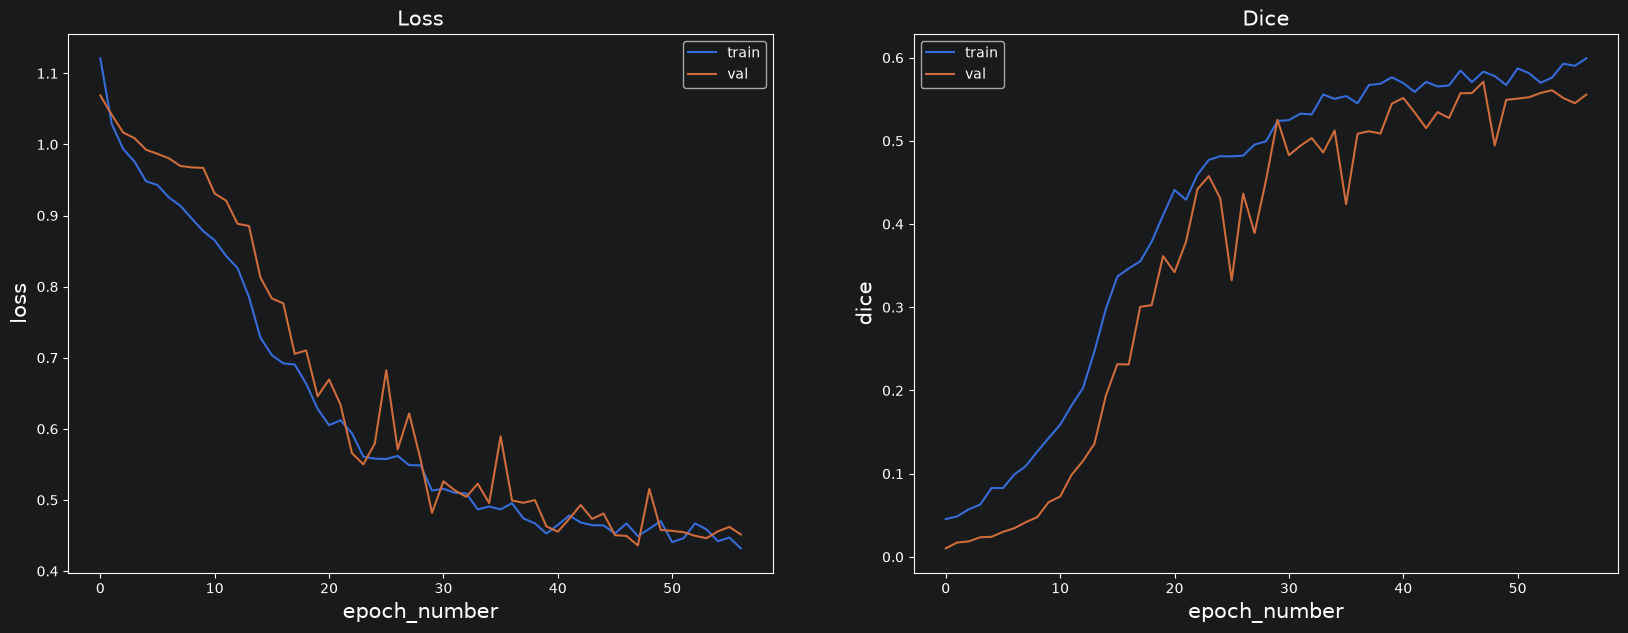

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [6]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='final_model', n_epochs=200, patience=10
)

## Расчет метрик

In [9]:
# Инициализации 3D U-Net ++ с обученными весами
unet_plus_plus = BasicUNetPlusPlus(
    spatial_dims=3,
    in_channels=3,
    out_channels=1,
    features=(32, 64, 128, 256, 512, 32)
).to(device)

unet_plus_plus.load_state_dict(torch.load('./weights/final_model/best_BasicUNetPlusPlus.pth'))

BasicUNetPlusPlus features: (32, 64, 128, 256, 512, 32).


<All keys matched successfully>

In [10]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
12,0.7,0.884615,0.851852,0.867925,0.620473,0.494606,29.132399,0.922466,7.902387e-12


In [11]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [12]:
# Метрики для всех очагов
all_lesion_metrics

,patient_group,patient_count,recall,precision,f1,spearman_coef,spearman_p_value,all_dice,all_dice_std,all_iou,all_iou_std,all_hd,all_hd_std
0,multiple_mixed_lesion,17,0.941176,0.941176,0.941176,0.906863,5.182873e-07,0.554731,0.163867,0.428972,0.140561,10.110754,14.085021
1,multiple_only_large_lesion,4,1.000000,1.000000,1.000000,0.400000,6.000000e-01,0.624559,0.291404,0.506574,0.277493,9.378690,15.762667
2,one_large_lesion,4,0.750000,0.750000,0.750000,0.800000,2.000000e-01,0.779232,0.125858,0.652460,0.183266,1.059017,0.915411
3,no_lesion,1,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
4,multiple_only_small_lesion,1,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN


In [13]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.596882,0.179160,0.468078,0.158646,10.169637,14.002553
1,multiple_only_large_lesion,4,0.624559,0.291404,0.506574,0.277493,9.378690,15.762667
2,one_large_lesion,4,0.779232,0.125858,0.652460,0.183266,1.059017,0.915411


In [14]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.152772,0.24872,0.109317,0.188559,3.606288,10.864848
4,multiple_only_small_lesion,1,0.000000,NaN,0.000000,NaN,0.000000,NaN


### Визуальный анализ

In [15]:
# Выделение пациентов с лучшими и худшими метриками Dice
best_dice_patients_idx, worst_dice_patients_idx = best_worst_patient_segmentation(test_df, patients_dice_df)

#### Лучшие случаи сегментации

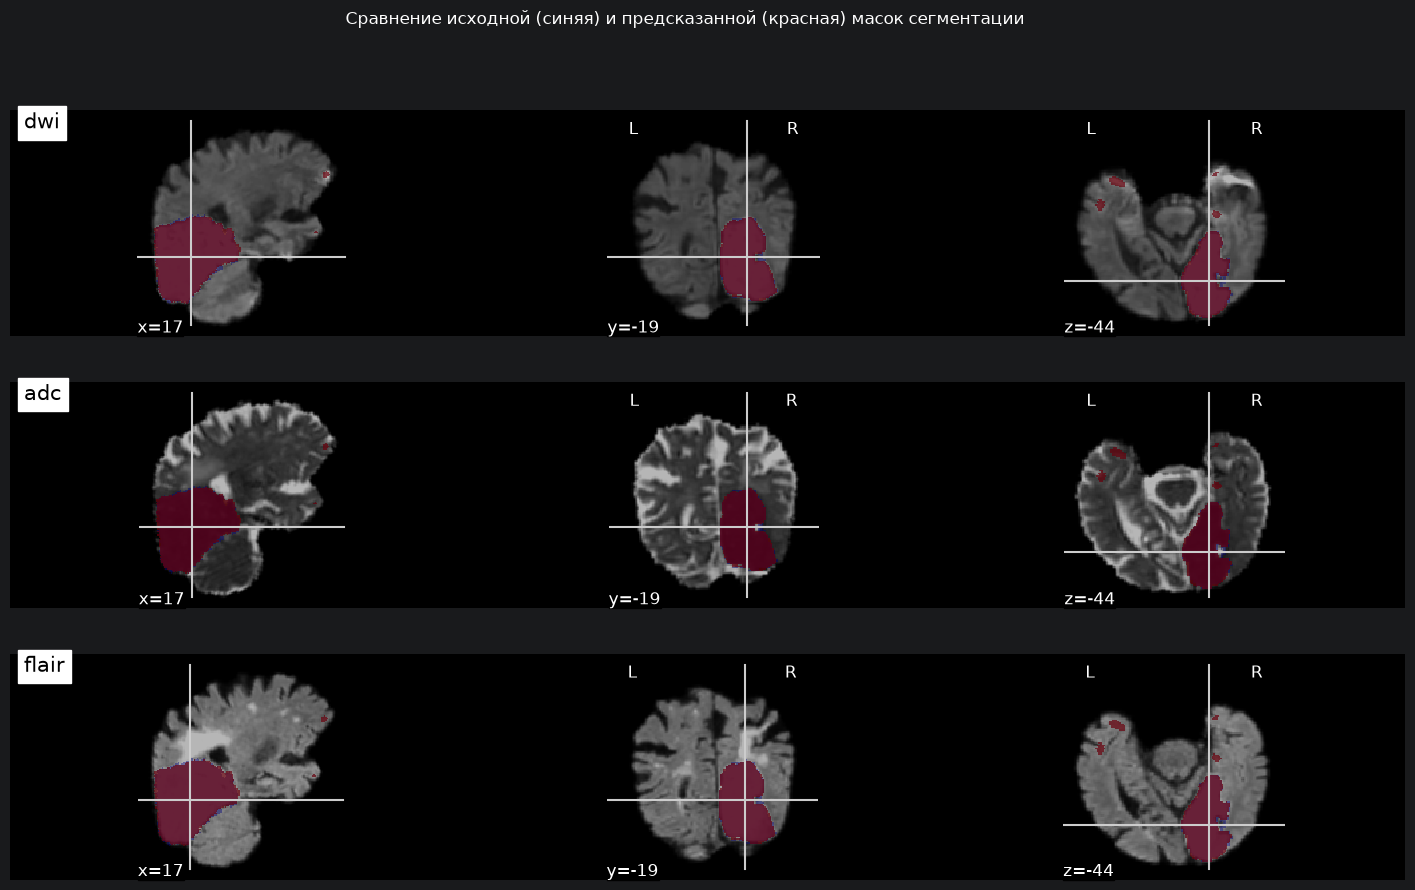

In [16]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

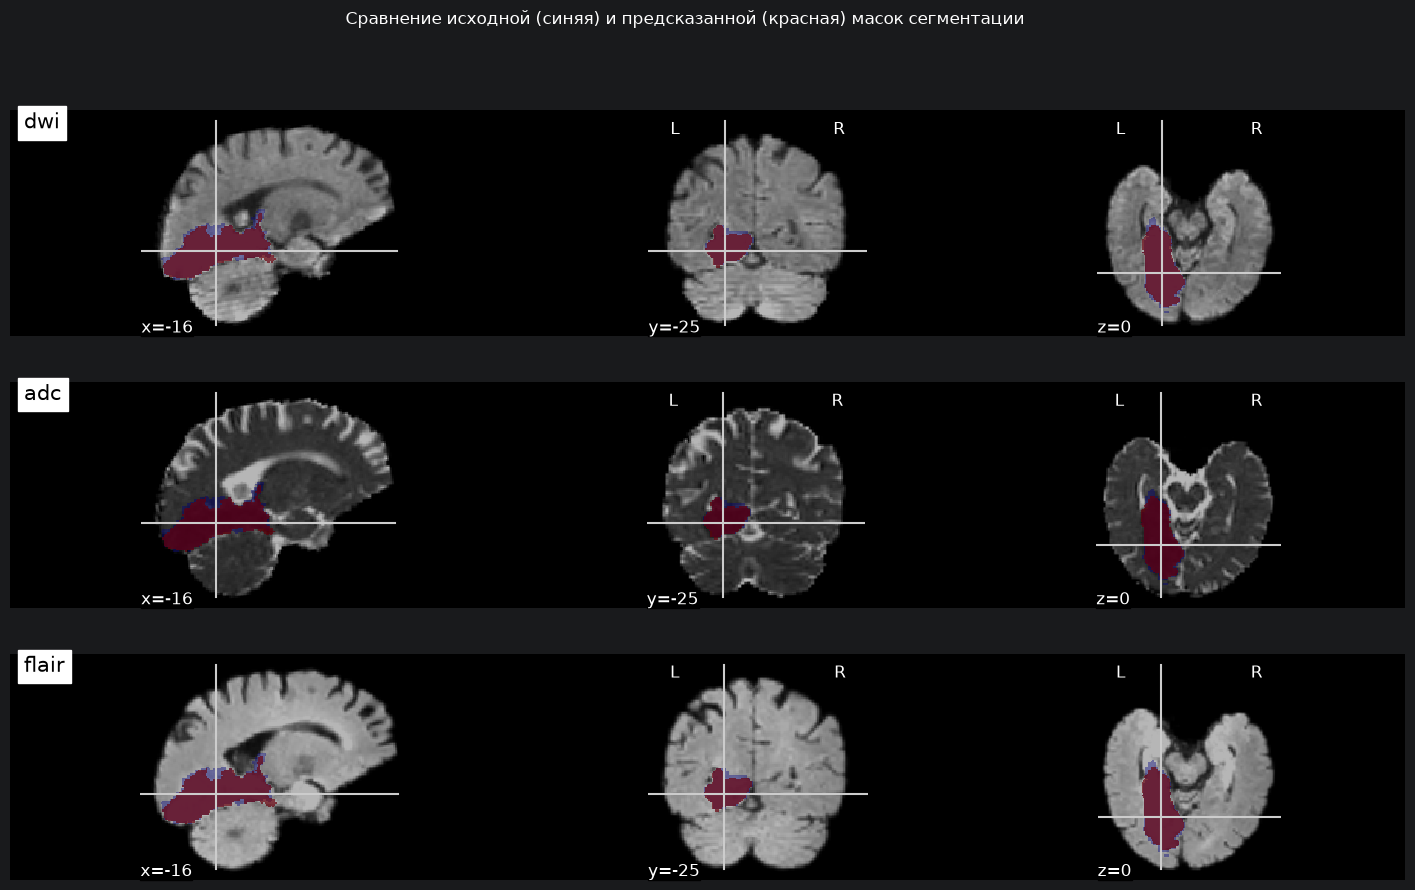

In [17]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

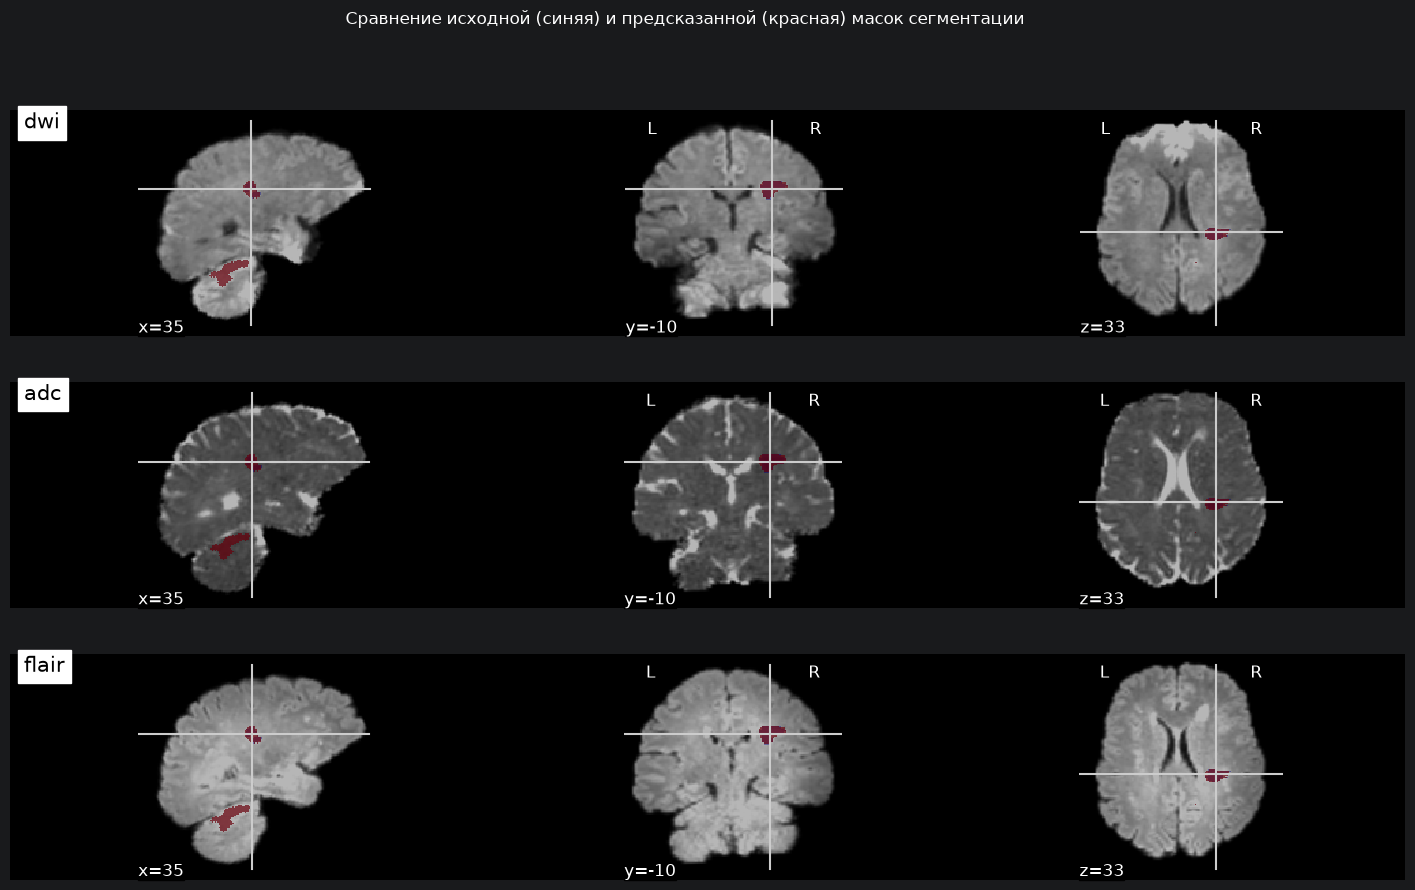

In [18]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

#### Худшие случаи сегментации

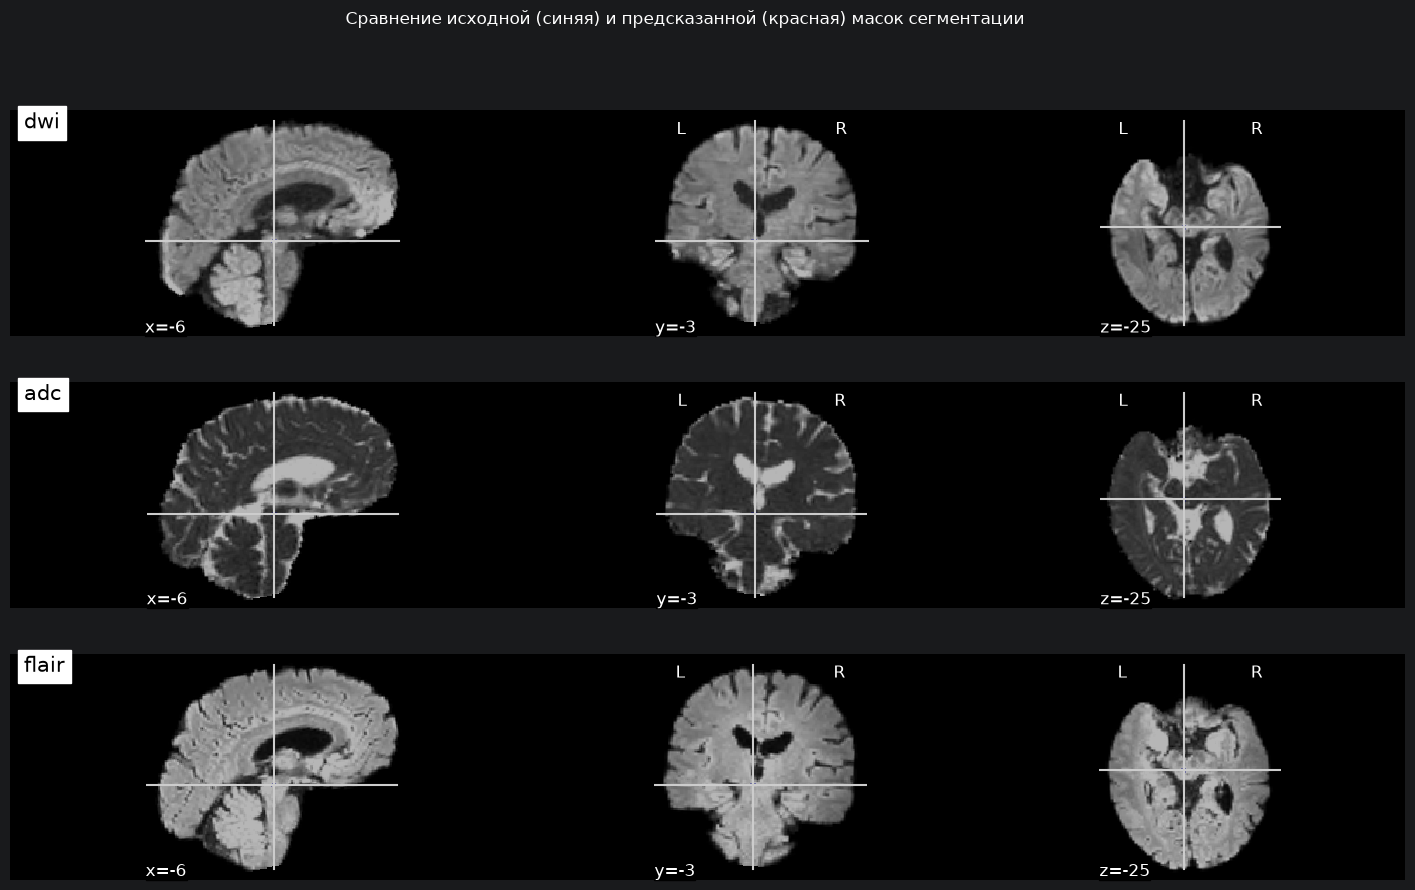

In [19]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

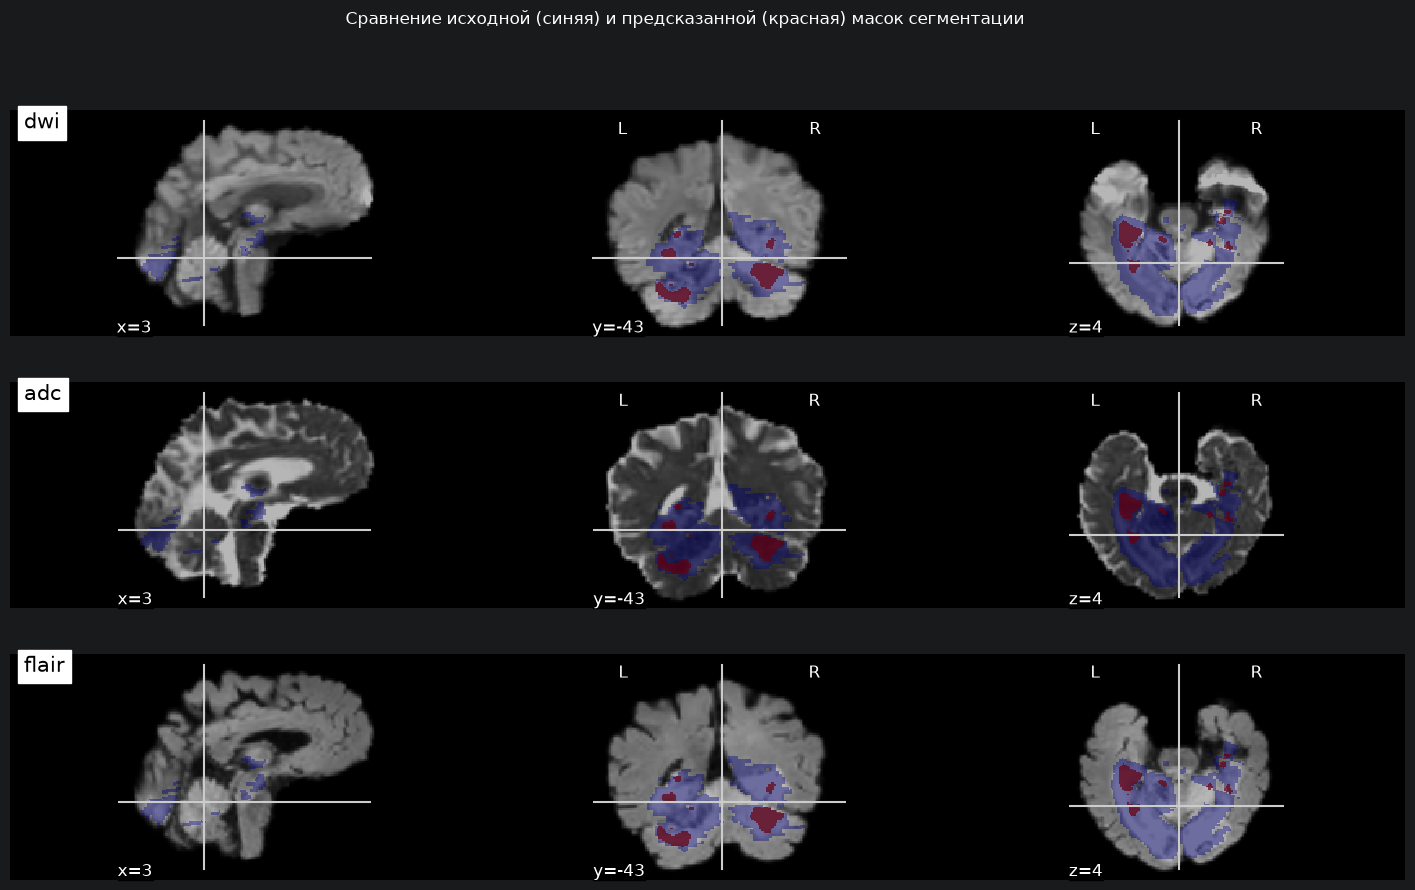

In [20]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

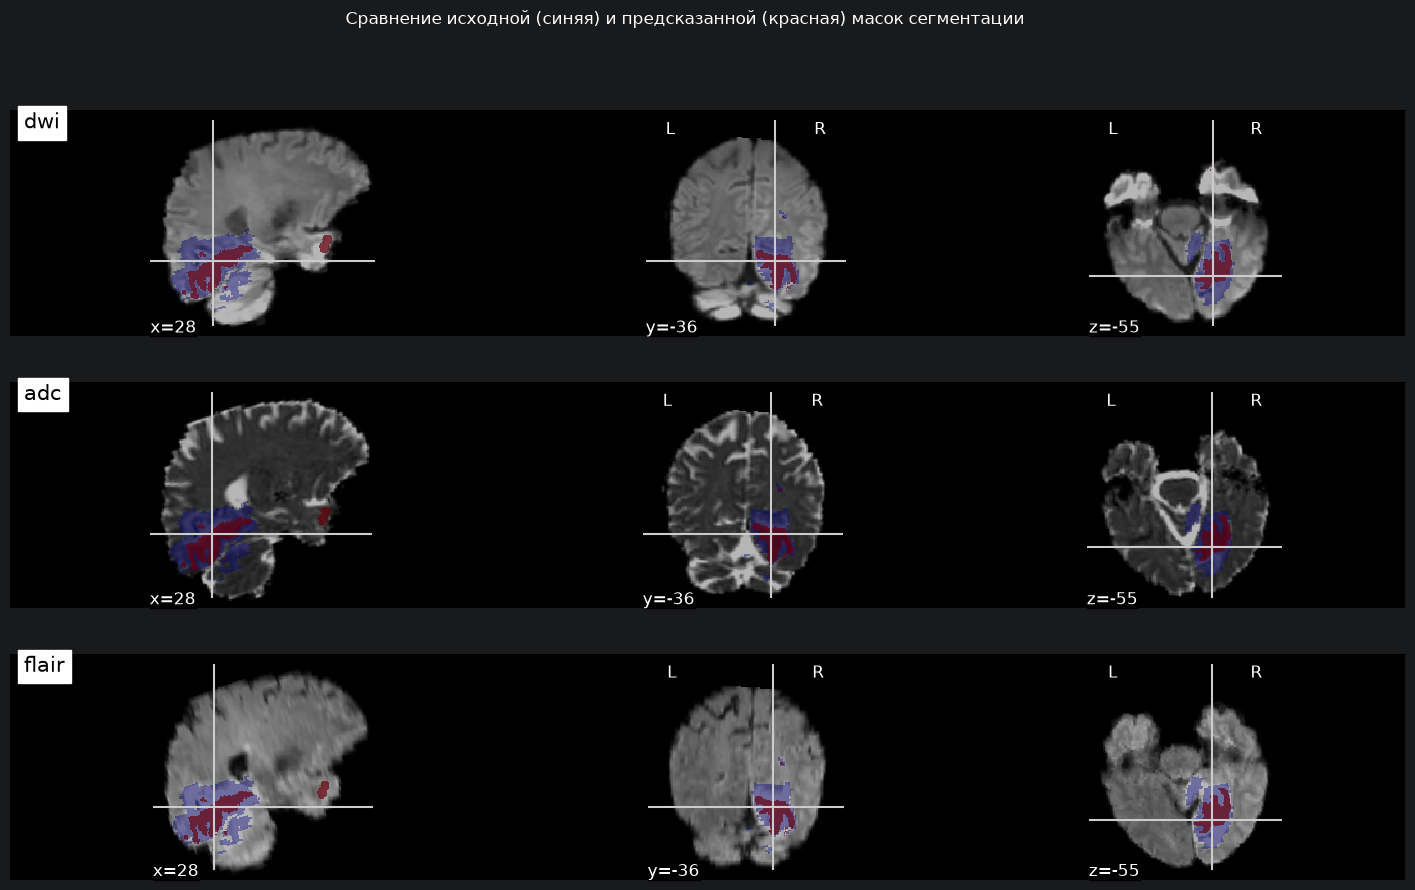

In [21]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

Увеличение ширины каналов сети привело к общему снижению качества модели и не повысило качество сегментации очагов малого размера

### Увеличение градиентного накопления

In [16]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

# Инициализации функции потерь, оптимизатора и планировщика
criterion = DiceFocalLoss(sigmoid=True, gamma=2.0, lambda_dice=1.0, lambda_focal=1.0)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


Epoch 120 of 200
train loss: 	0.420046
val loss: 	0.401264
train dice: 			0.61
val dice: 			0.60


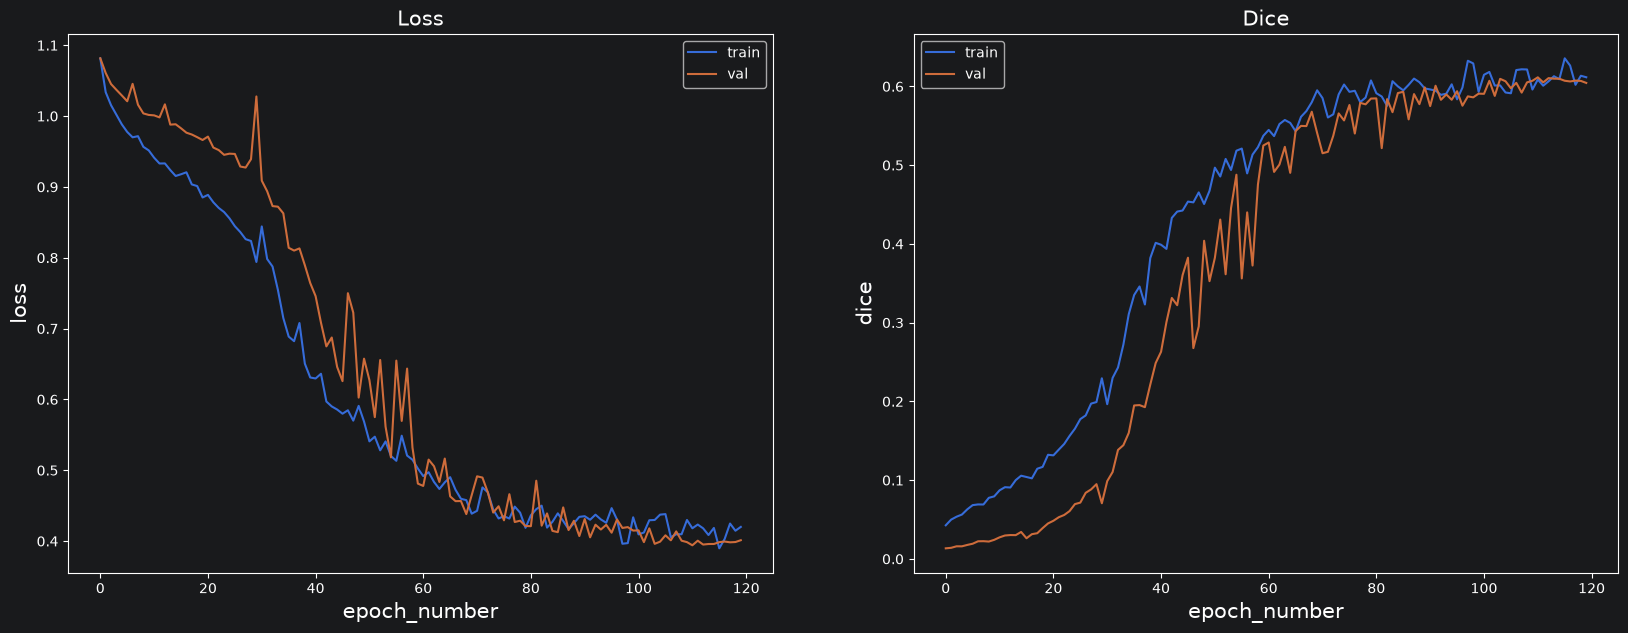

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [17]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='final_model', n_epochs=200, patience=10, gradient_accumulation_steps=16
)

### Расчет метрик

In [4]:
# Инициализации 3D U-Net ++ с обученными весами
unet_plus_plus = get_unet_plus_plus_for_refinement(weights_dir='final_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [22]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
13,0.75,0.923077,0.888889,0.90566,0.653991,0.53157,26.793942,0.942613,2.052583e-13


In [5]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [6]:
# Метрики для всех очагов
all_lesion_metrics

,patient_group,patient_count,recall,precision,f1,spearman_coef,spearman_p_value,all_dice,all_dice_std,all_iou,all_iou_std,all_hd,all_hd_std
0,multiple_mixed_lesion,17,1.00,1.00,1.00,0.968137,1.990990e-10,0.611953,0.160051,0.479827,0.139878,8.951619,14.508863
1,multiple_only_large_lesion,4,1.00,1.00,1.00,0.400000,6.000000e-01,0.669723,0.252387,0.547459,0.250476,8.154093,13.450841
2,one_large_lesion,4,0.75,0.75,0.75,0.800000,2.000000e-01,0.790720,0.124005,0.667760,0.180819,0.750000,0.500000
3,no_lesion,1,0.00,0.00,0.00,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
4,multiple_only_small_lesion,1,0.00,0.00,0.00,NaN,NaN,0.580645,NaN,0.409091,NaN,1.000000,NaN


In [7]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.644697,0.165544,0.513002,0.148816,8.936847,14.391061
1,multiple_only_large_lesion,4,0.669723,0.252387,0.547459,0.250476,8.154093,13.450841
2,one_large_lesion,4,0.790720,0.124005,0.667760,0.180819,0.750000,0.500000


In [8]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.148695,0.254867,0.106263,0.19307,3.667015,11.954271
4,multiple_only_small_lesion,1,0.580645,NaN,0.409091,NaN,1.000000,NaN


### Визуальный анализ

In [9]:
# Выделение пациентов с лучшими и худшими метриками Dice
best_dice_patients_idx, worst_dice_patients_idx = best_worst_patient_segmentation(test_df, patients_dice_df)

#### Лучшие случаи сегментации

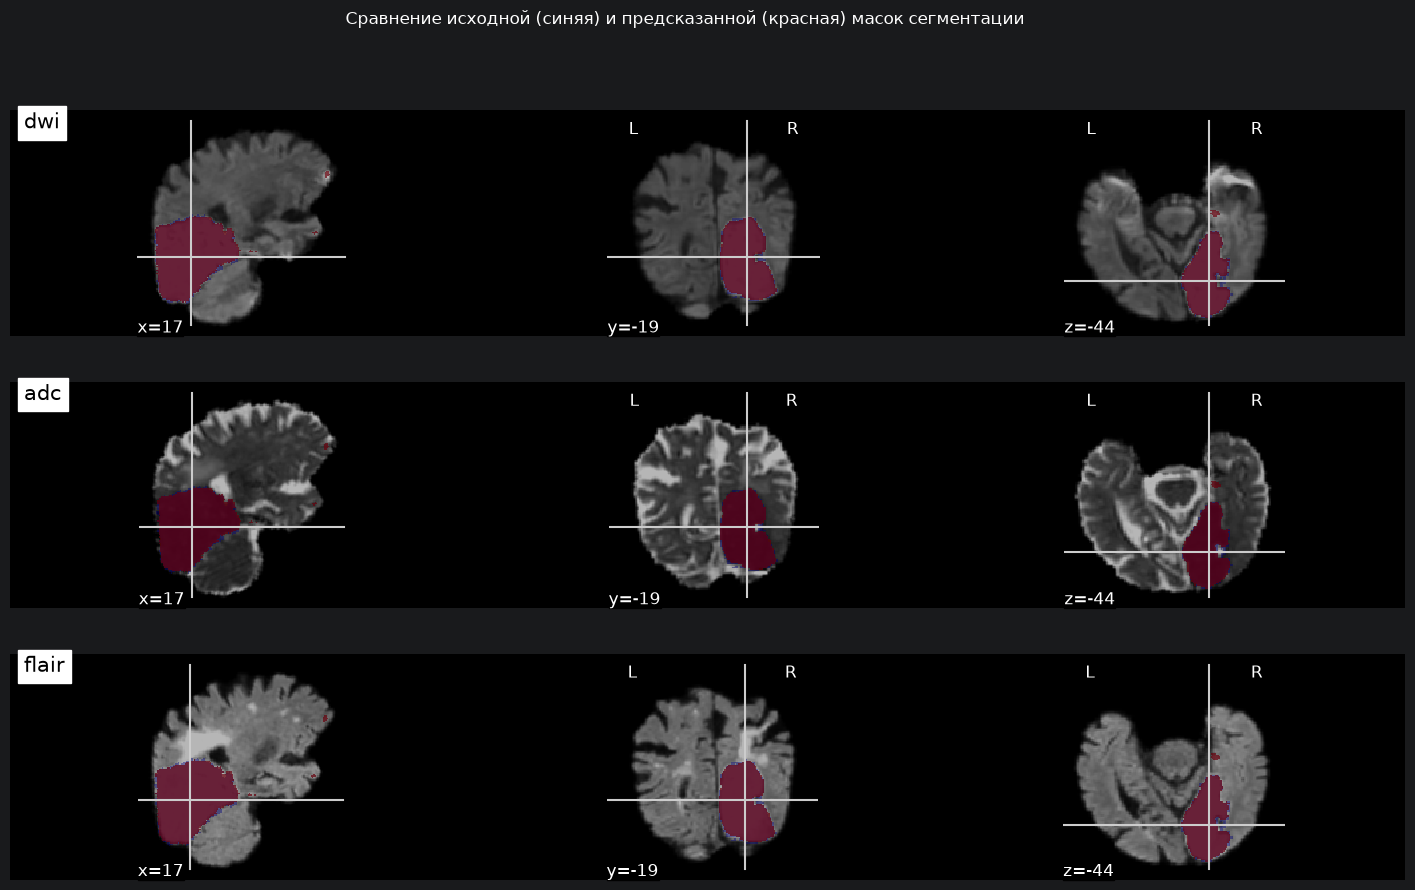

In [10]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

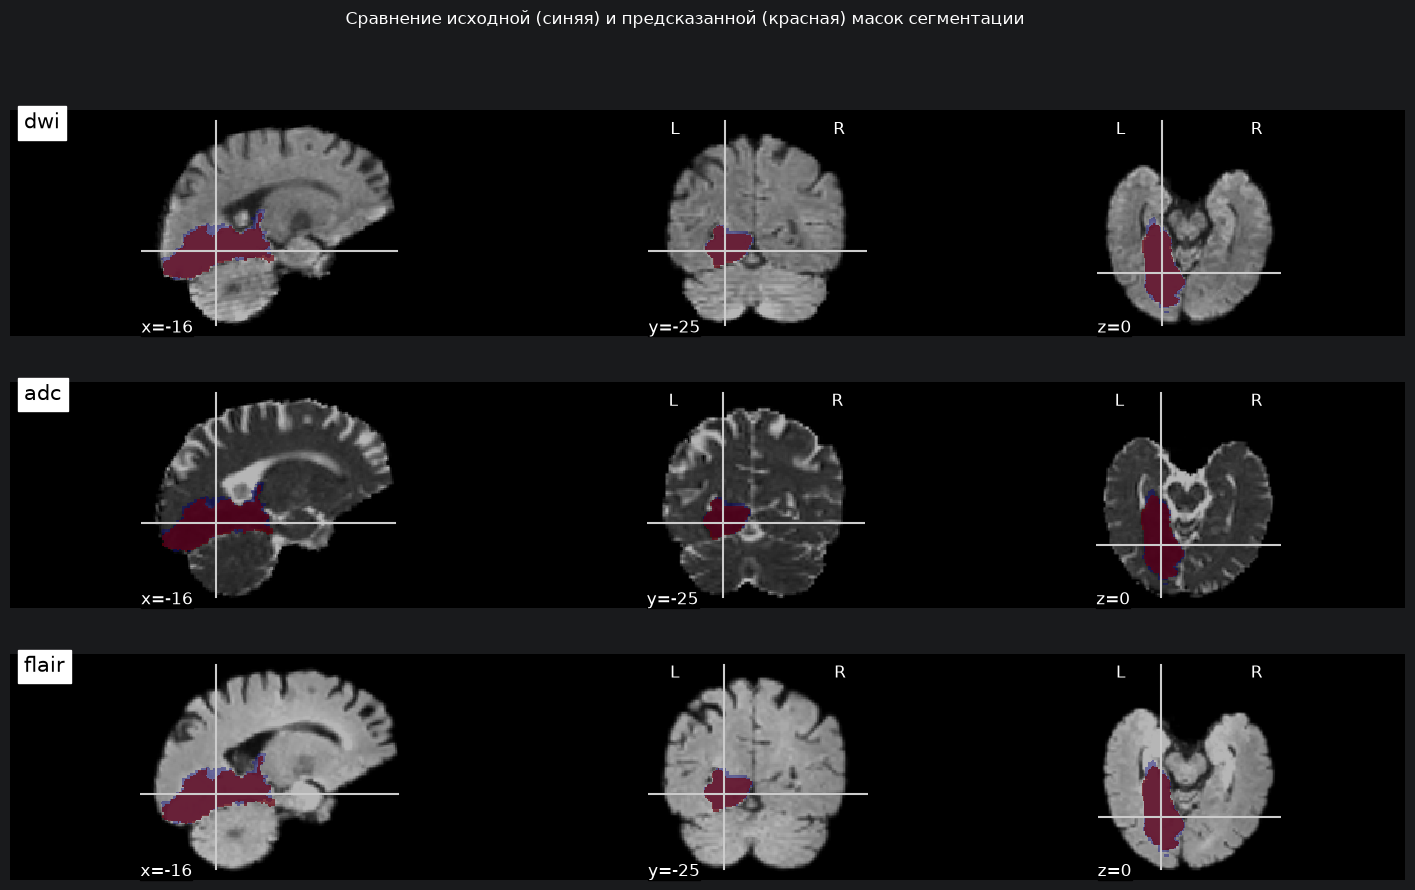

In [11]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

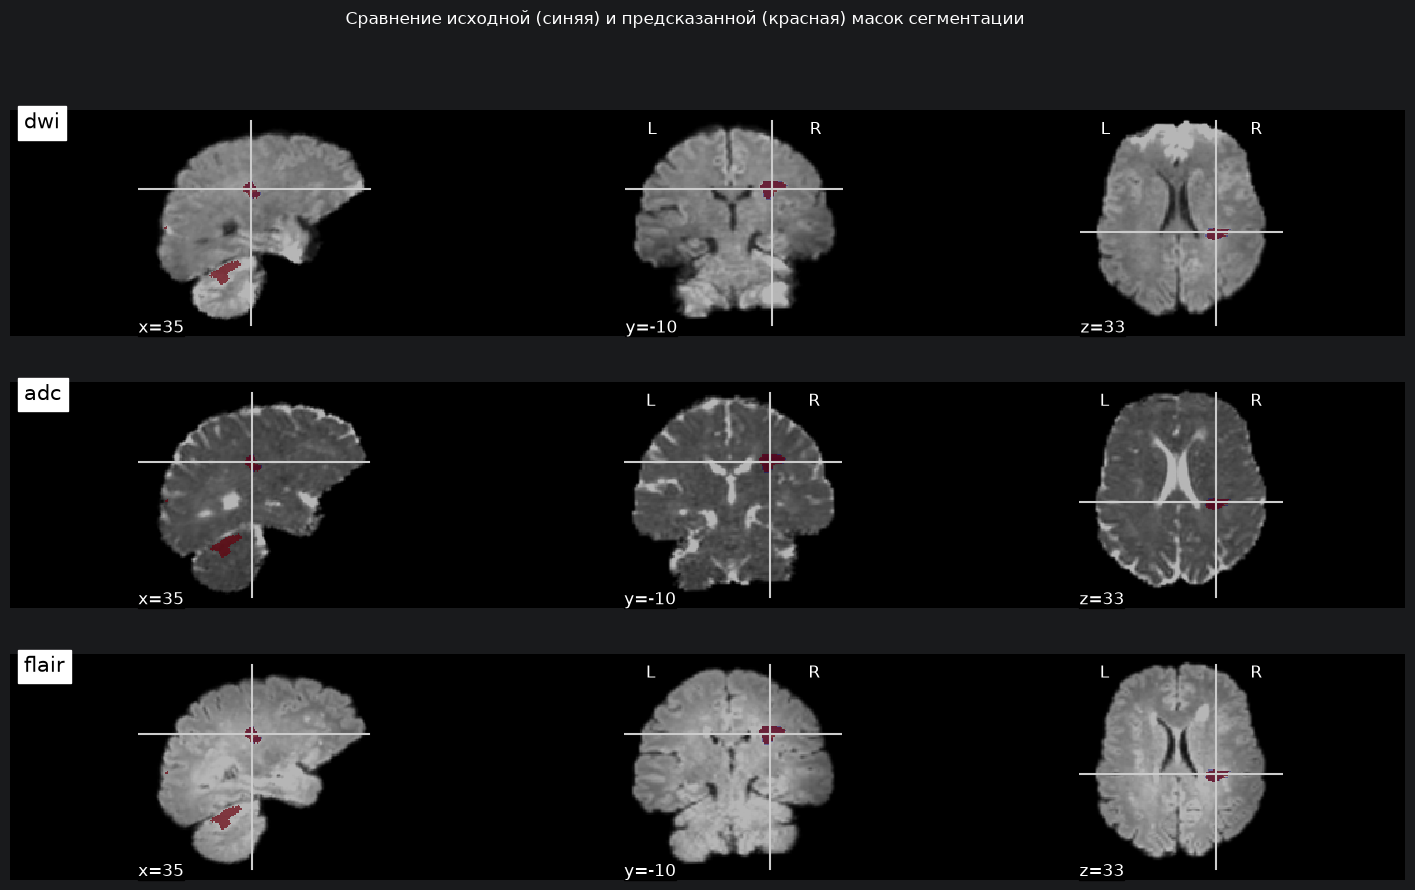

In [12]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

#### Худшие случаи сегментации

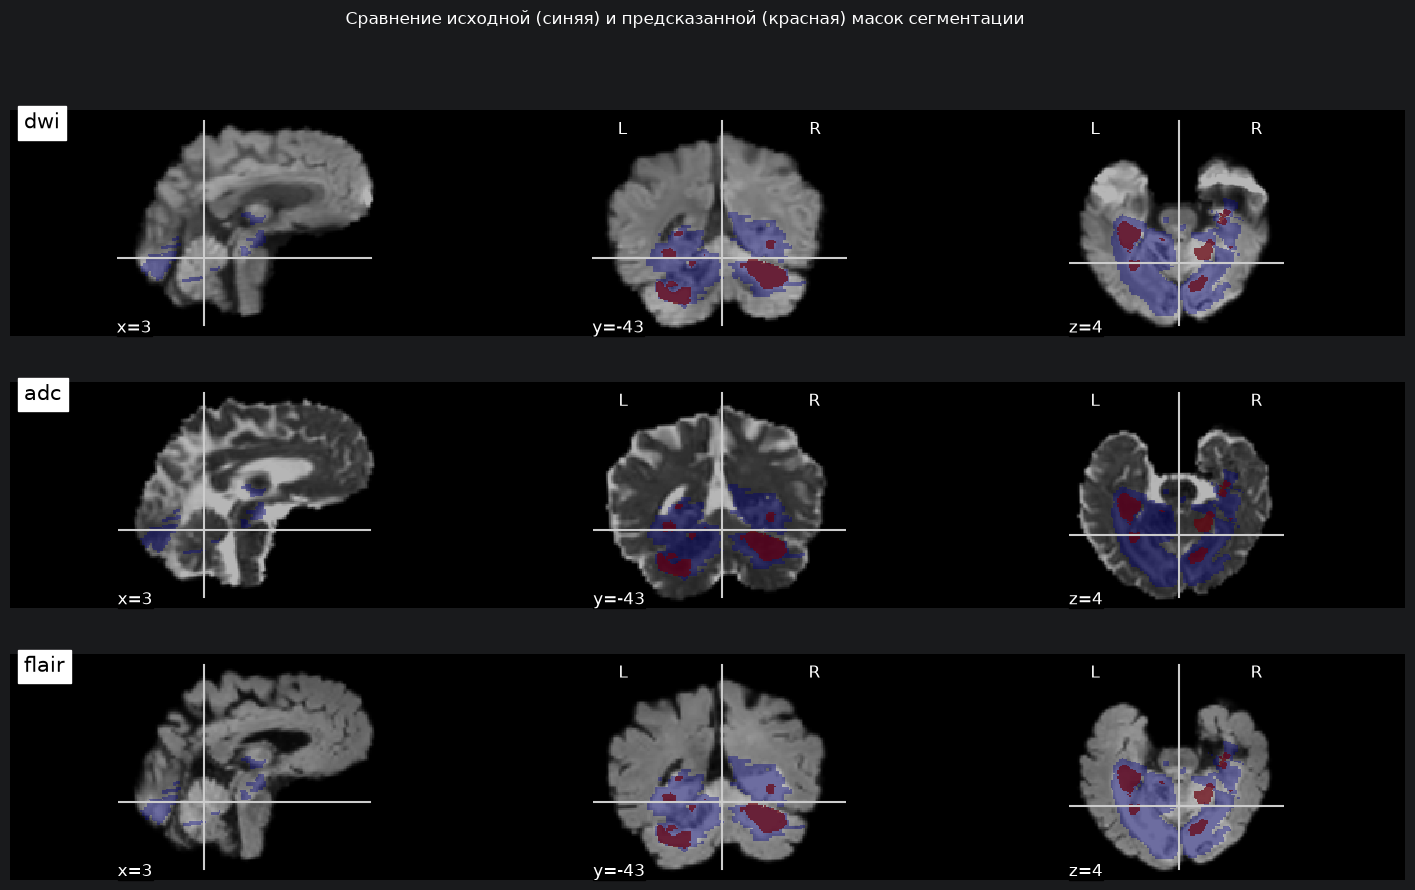

In [13]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

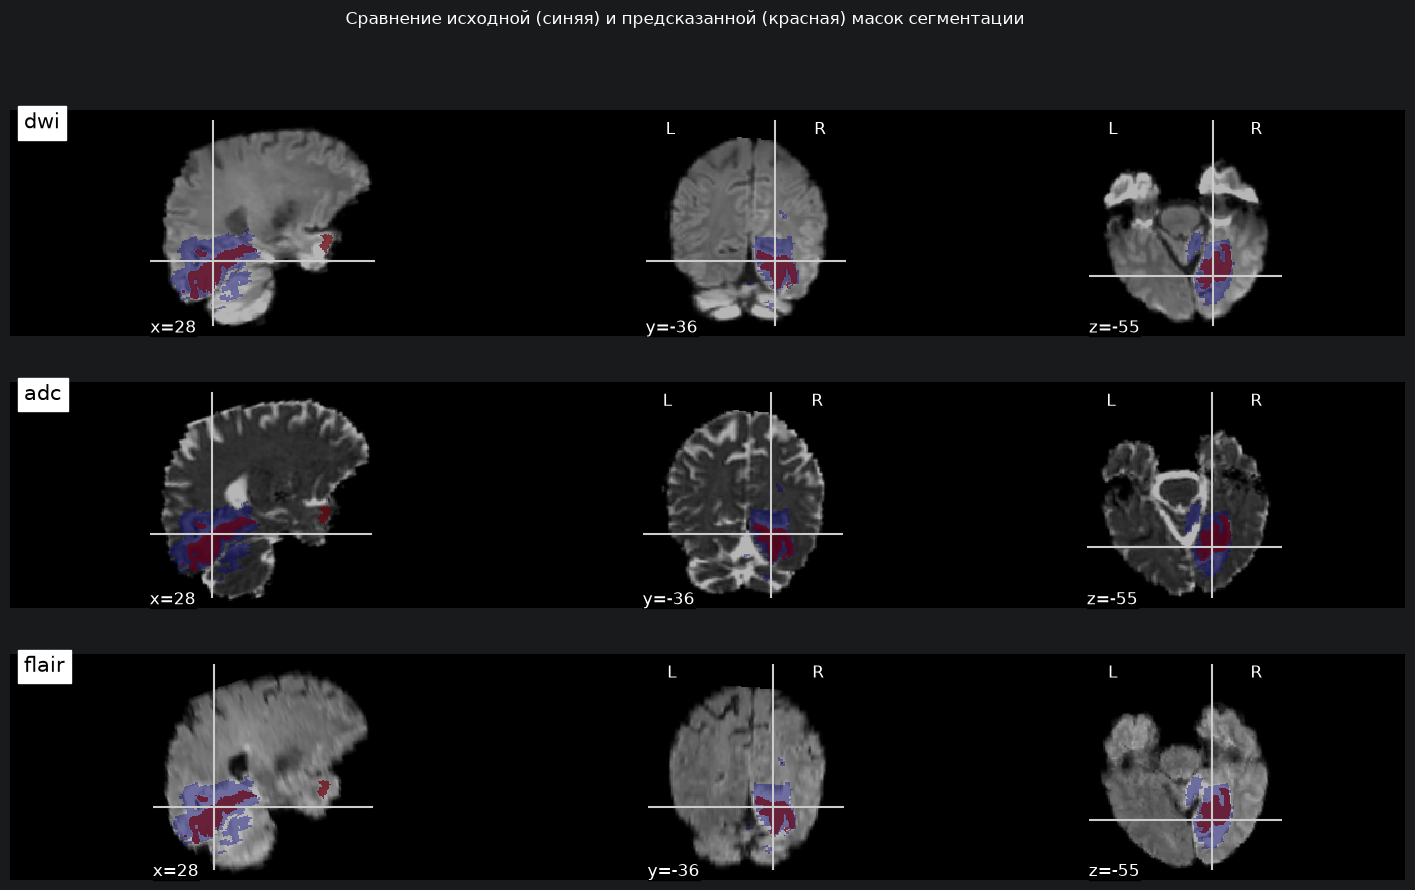

In [14]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

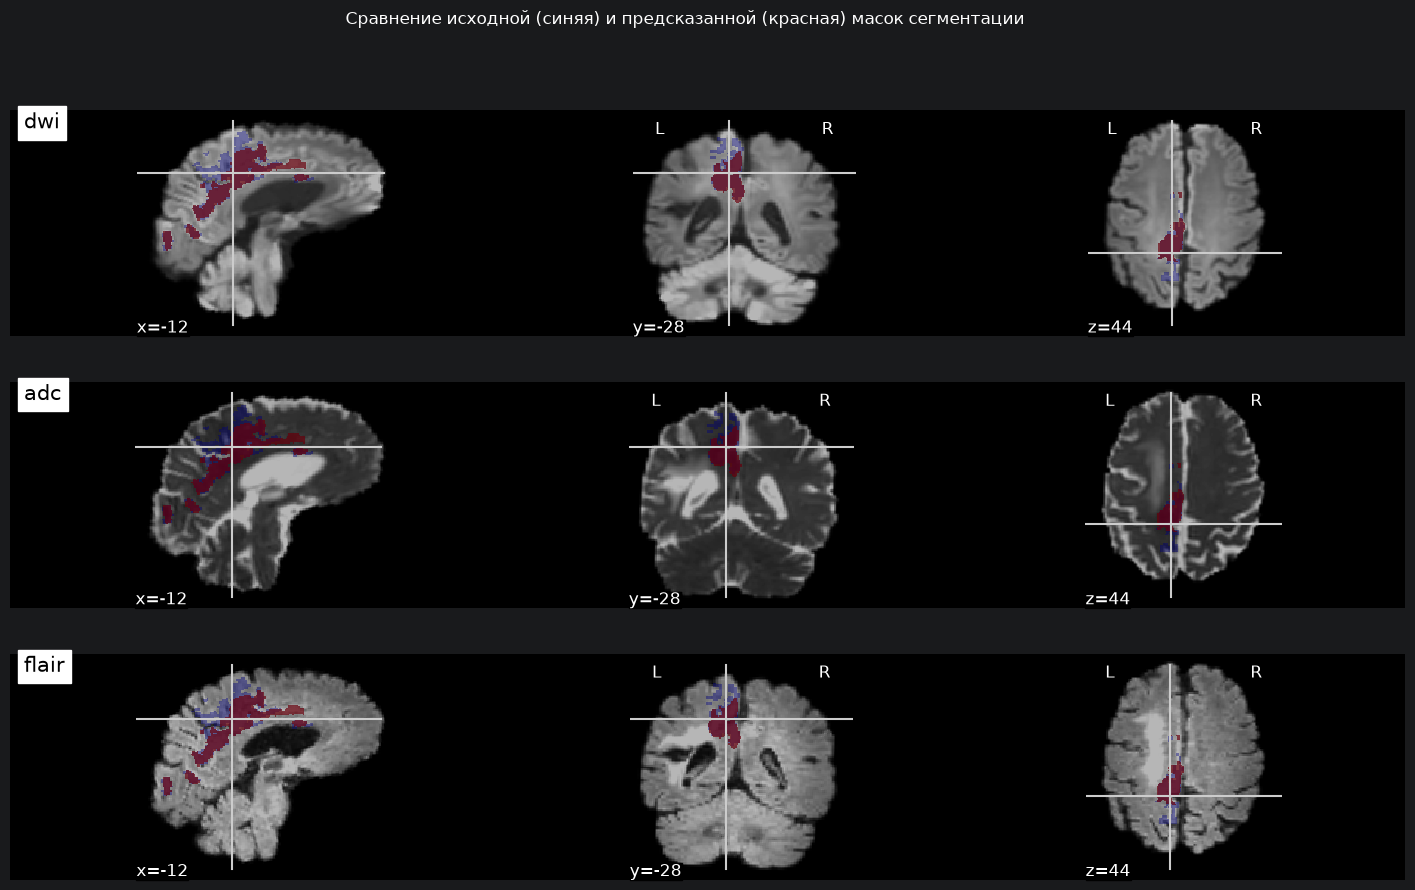

In [15]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

Увеличение градиентного накопления также привело к общему снижению качества модели и не повысило качество сегментации очагов малого размера

## Попробуем заменить функцию потерь на более чувствительную к мелким очагам

In [16]:
# Инициализация модели
unet_plus_plus = get_unet_plus_plus_for_refinement()

# Инициализации функции потерь, оптимизатора и планировщика
criterion = TverskyLoss(sigmoid=True, alpha=0.3,beta=0.7)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


Epoch 75 of 200
train loss: 	0.368140
val loss: 	0.381627
train dice: 			0.60
val dice: 			0.55


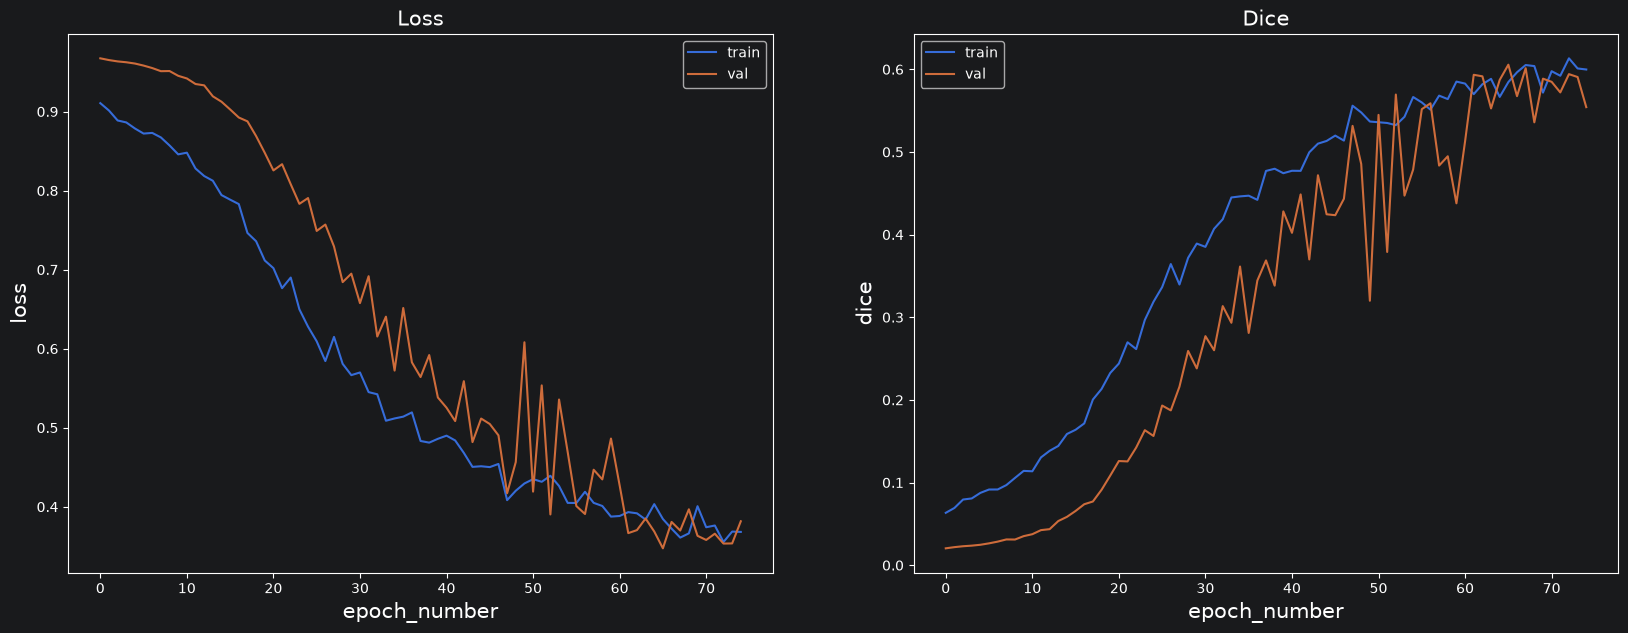

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [17]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='final_model', n_epochs=200, patience=10
)

### Расчет метрик

In [4]:
# Инициализации 3D U-Net ++ с обученными весами
unet_plus_plus = get_unet_plus_plus_for_refinement(weights_dir='final_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [19]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
17,0.95,0.884615,0.851852,0.867925,0.621082,0.49859,36.08006,0.969475,8.884858e-17


In [7]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [21]:
# Метрики для всех очагов
all_lesion_metrics

,patient_group,patient_count,recall,precision,f1,spearman_coef,spearman_p_value,all_dice,all_dice_std,all_iou,all_iou_std,all_hd,all_hd_std
0,multiple_mixed_lesion,17,1.0,1.0,1.0,0.963235,5.740995e-10,0.529942,0.128440,0.407503,0.108297,11.833602,13.893025
1,multiple_only_large_lesion,4,1.0,1.0,1.0,0.800000,2.000000e-01,0.704860,0.149930,0.565049,0.180874,17.457864,18.483490
2,one_large_lesion,4,0.5,0.5,0.5,0.800000,2.000000e-01,0.739823,0.160642,0.608164,0.221113,0.957107,0.667280
3,no_lesion,1,0.0,0.0,0.0,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
4,multiple_only_small_lesion,1,0.0,0.0,0.0,NaN,NaN,0.174031,NaN,0.098135,NaN,3.667544,NaN


In [22]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.588552,0.148670,0.460160,0.129818,12.380098,13.973592
1,multiple_only_large_lesion,4,0.704860,0.149930,0.565049,0.180874,17.457864,18.483490
2,one_large_lesion,4,0.739823,0.160642,0.608164,0.221113,0.957107,0.667280


In [23]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.124085,0.201374,0.083264,0.141956,3.802585,11.612064
4,multiple_only_small_lesion,1,0.174031,NaN,0.098135,NaN,3.667544,NaN


### Визуальный анализ

In [8]:
# Выделение пациентов с лучшими и худшими метриками Dice
best_dice_patients_idx, worst_dice_patients_idx = best_worst_patient_segmentation(test_df, patients_dice_df)

#### Лучшие случаи сегментации

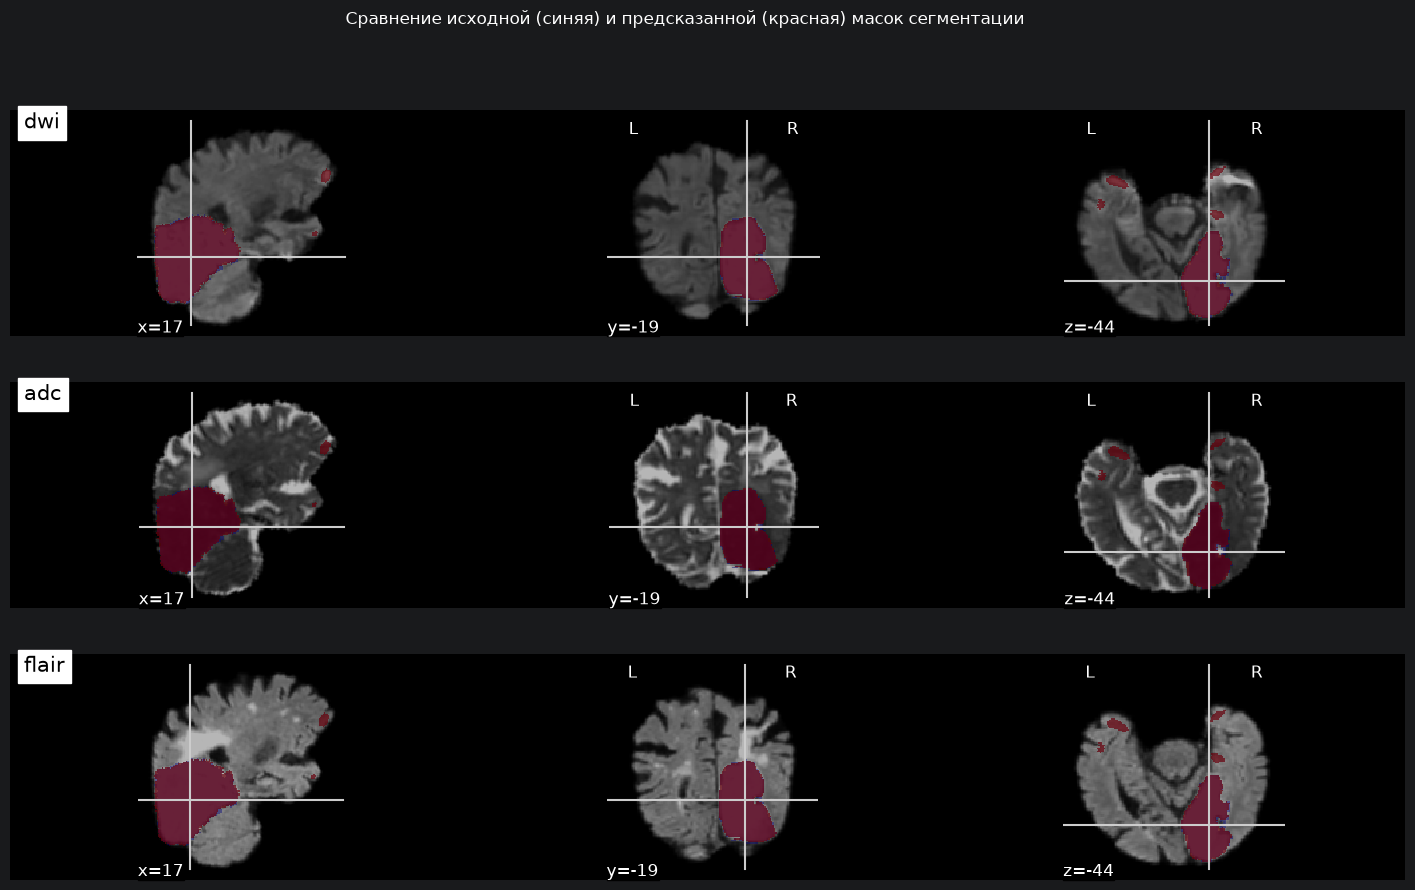

In [9]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

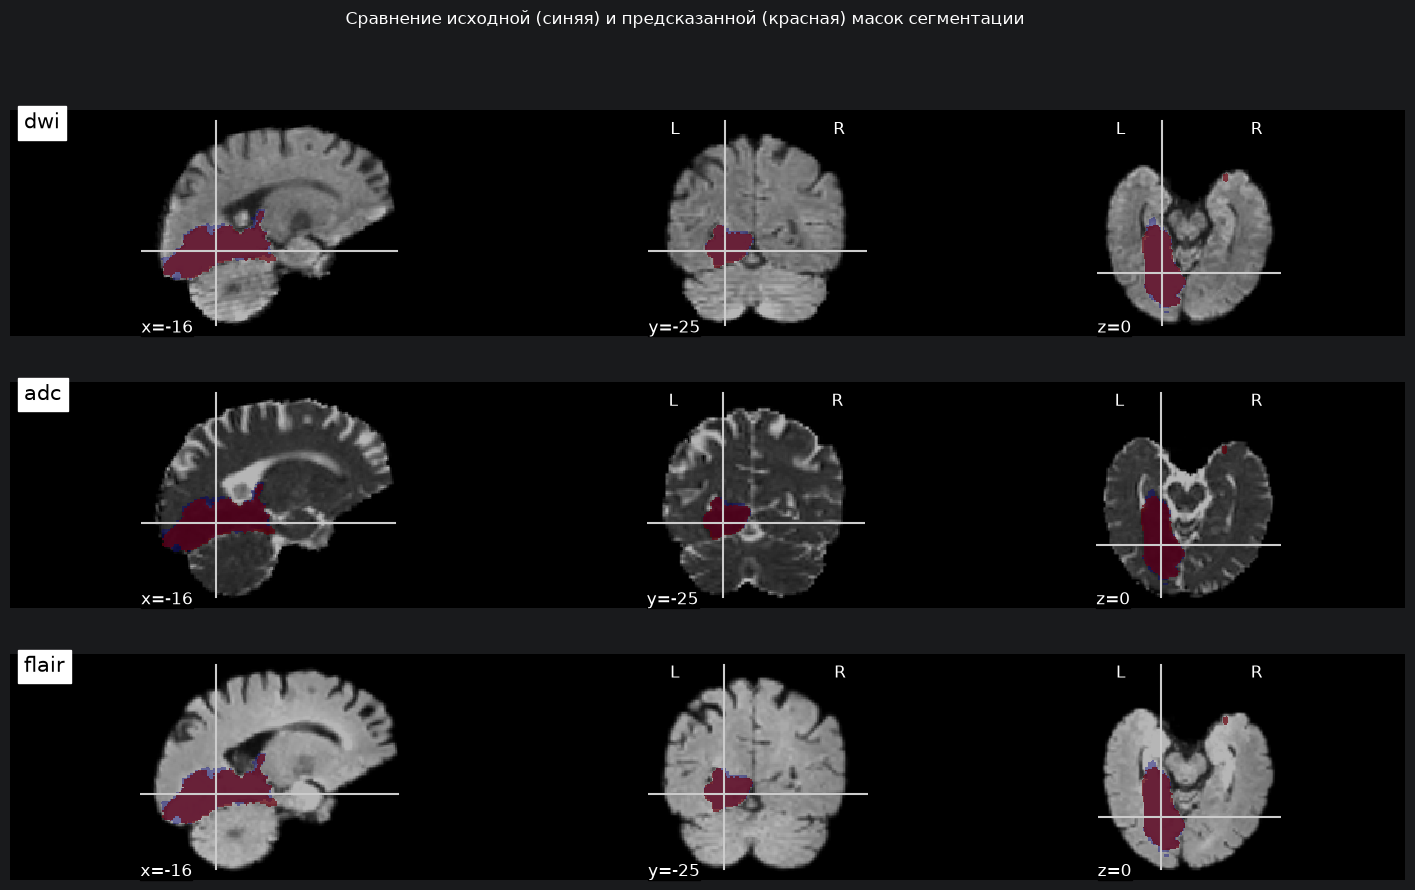

In [10]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

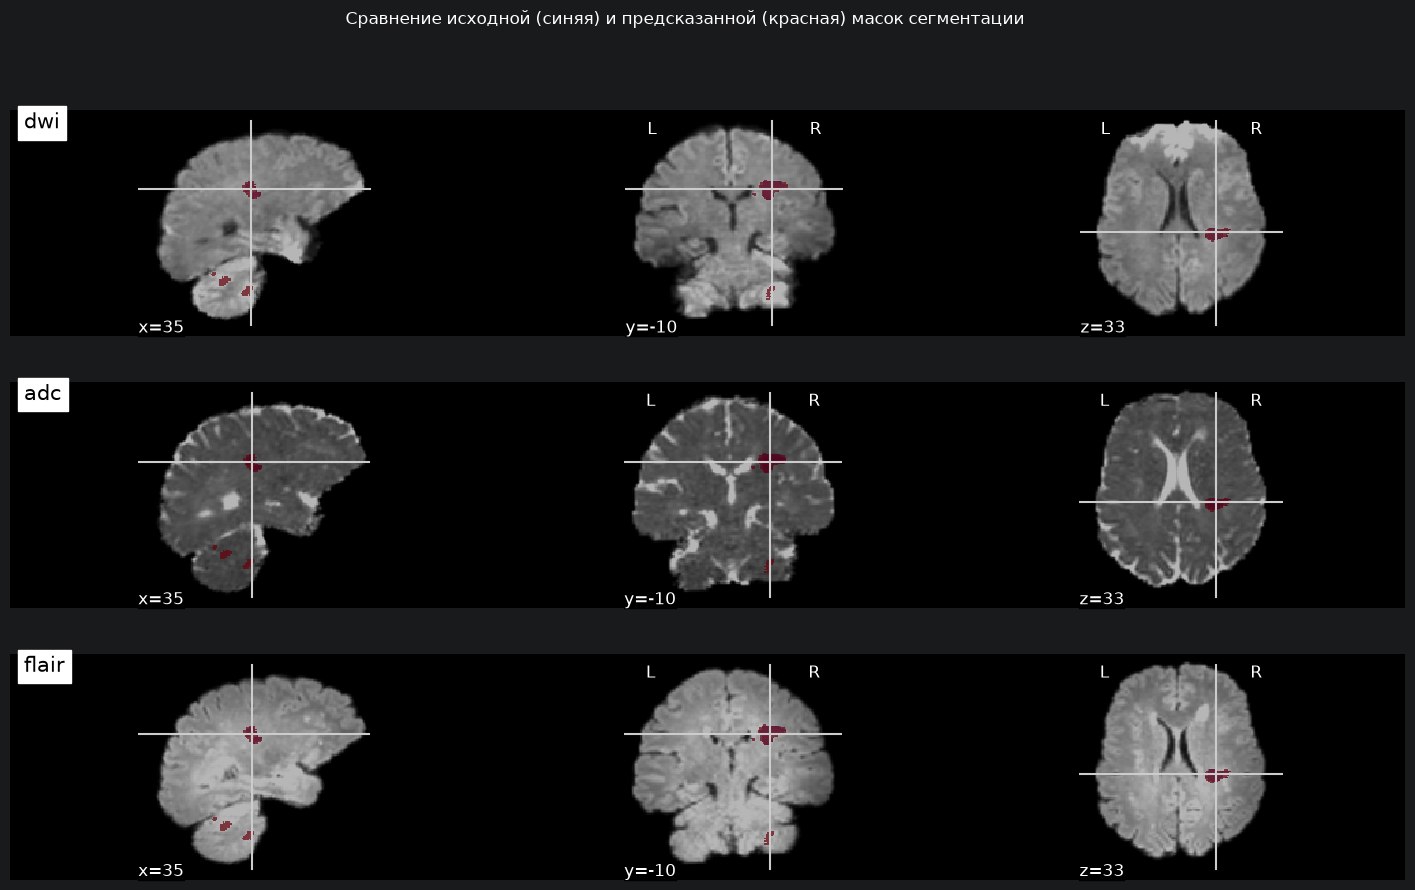

In [11]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

#### Худшие случаи сегментации

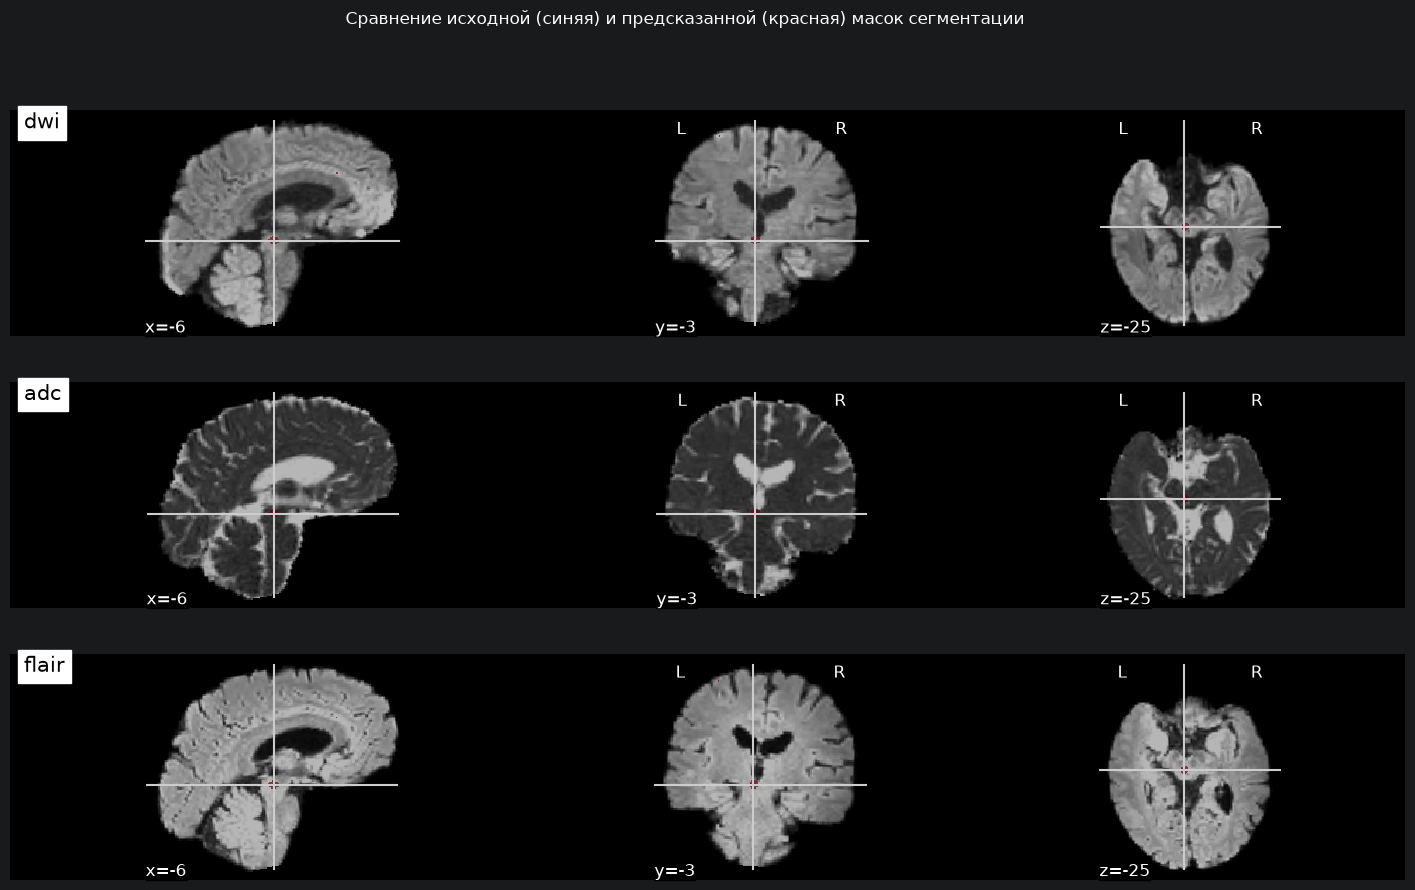

In [12]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

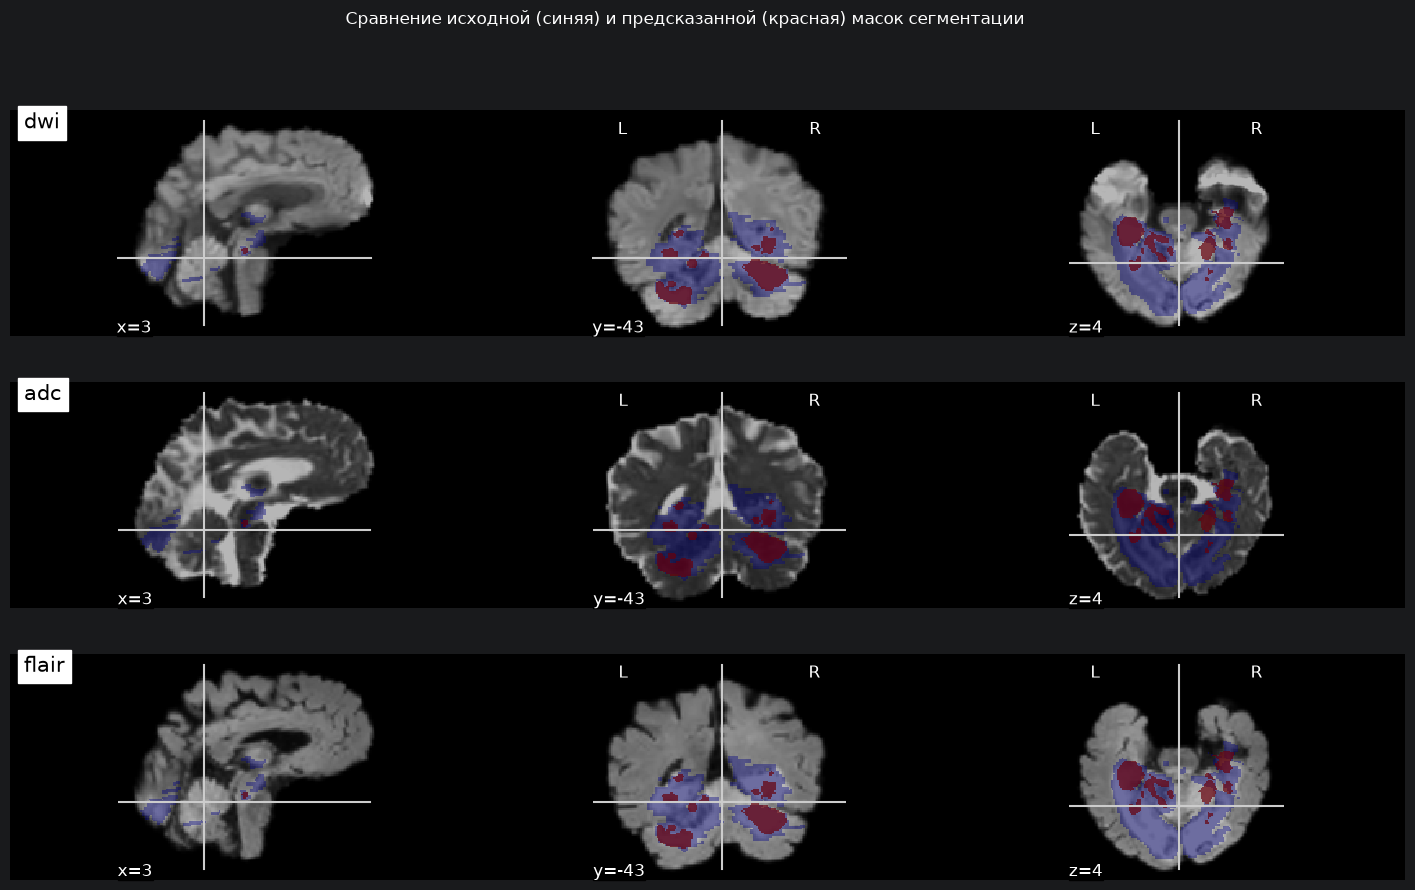

In [13]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

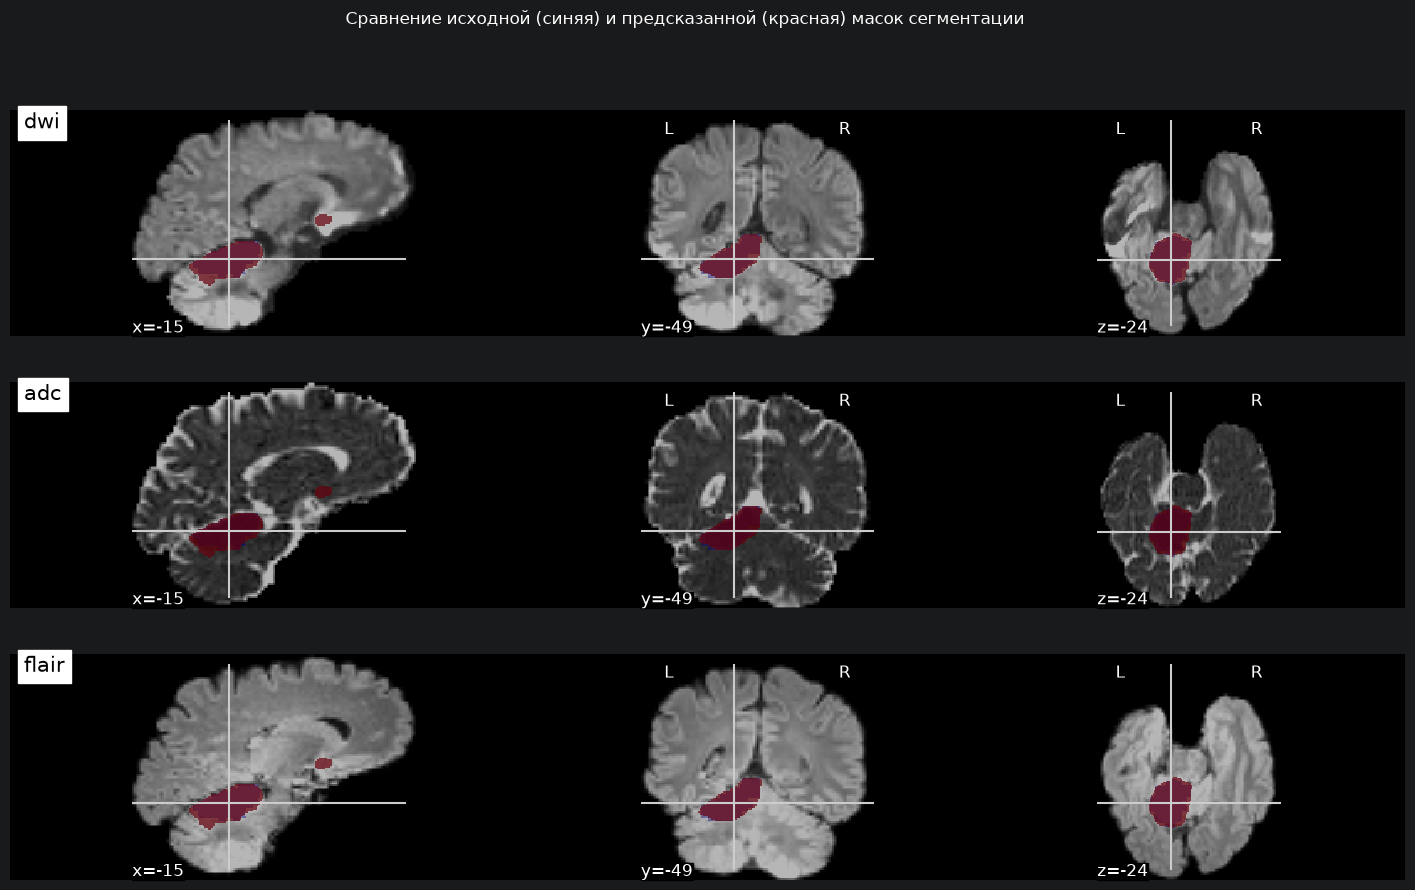

In [14]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

Замена функции потерь также привела к общему снижению качества модели и не повысила качество сегментации очагов малого размера

## Добавим к сети deep supervision

In [5]:
# Инициализации модели
unet_plus_plus = BasicUNetPlusPlus(
    spatial_dims=3,
    in_channels=3,
    out_channels=1,
    features=(16, 32, 64, 128, 256, 16),
    deep_supervision=True
    ).to(device)

# Инициализации функции потерь, оптимизатора и планировщика
criterion = DiceFocalLoss(sigmoid=True, gamma=2.0, lambda_dice=1.0, lambda_focal=1.0)
optimizer = torch.optim.AdamW(unet_plus_plus.parameters(), lr=0.001, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


Epoch 70 of 200
train loss: 	0.466768
val loss: 	0.460587
train dice: 			0.59
val dice: 			0.55


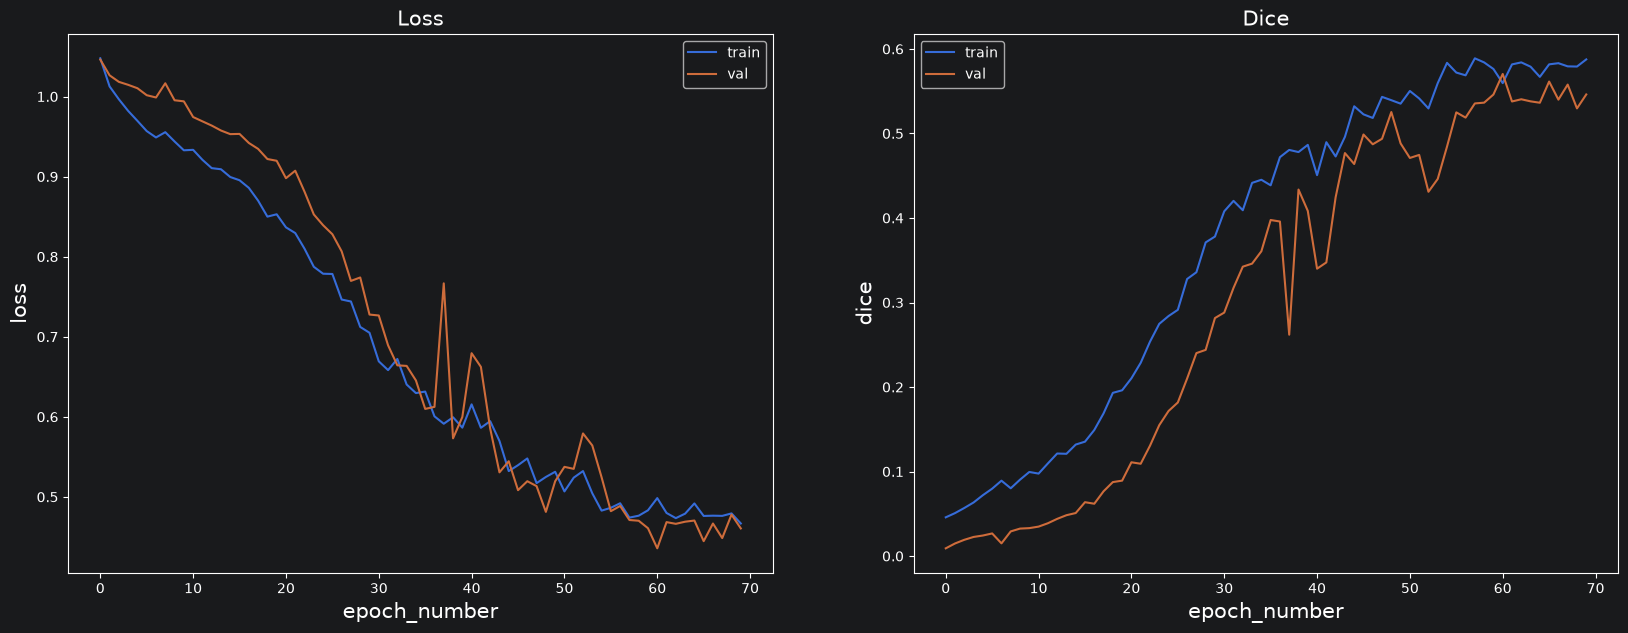

  0%|          | 0/198 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [6]:
# Обучение модели
train_model(
    unet_plus_plus, criterion, optimizer, scheduler, train, val,
    weights_dir_name='final_model', deep_supervision_weights=[0.1, 0.2, 0.3, 0.4] , n_epochs=200, patience=10
)

### Расчет метрик

In [7]:
# Инициализации 3D U-Net ++ с обученными весами
unet_plus_plus = get_unet_plus_plus_for_refinement(weights_dir='final_model')

BasicUNetPlusPlus features: (16, 32, 64, 128, 256, 16).


In [8]:
# Определение оптимального порога уверенности и глобальных метрик на нем
thresholds_metrics, best_threshold = find_optim_threshold(unet_plus_plus, test)
thresholds_metrics

,threshold,recall,precision,f1,dice,iou,hd,spearman_coef,spearman_p_value
11,0.65,0.884615,0.851852,0.867925,0.608129,0.48386,30.405169,0.945665,1.053929e-13


In [9]:
# Вычисление метрик по группам пациентов и размерам очагов
all_lesion_metrics, big_lesion_metrics, small_lesion_metrics, patients_dice_df = (
    groups_metrics_reports(unet_plus_plus,  test_df, ['dwi', 'adc', 'flair'], threshold=best_threshold)
)

In [10]:
# Метрики для всех очагов
all_lesion_metrics

,patient_group,patient_count,recall,precision,f1,spearman_coef,spearman_p_value,all_dice,all_dice_std,all_iou,all_iou_std,all_hd,all_hd_std
0,multiple_mixed_lesion,17,0.941176,0.941176,0.941176,0.931373,5.642065e-08,0.571629,0.152388,0.441192,0.140173,9.978723,15.568952
1,multiple_only_large_lesion,4,1.000000,1.000000,1.000000,0.800000,2.000000e-01,0.629501,0.277622,0.510110,0.274096,17.691515,18.727085
2,one_large_lesion,4,0.750000,0.750000,0.750000,1.000000,0.000000e+00,0.748194,0.157648,0.618186,0.217599,0.957107,0.667280
3,no_lesion,1,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN
4,multiple_only_small_lesion,1,0.000000,0.000000,0.000000,NaN,NaN,0.680851,NaN,0.516129,NaN,1.000000,NaN


In [11]:
# Метрики для крупных очагов
big_lesion_metrics

,patient_group,patient_count,big_dice,big_dice_std,big_iou,big_iou_std,big_hd,big_hd_std
0,multiple_mixed_lesion,17,0.599089,0.155892,0.466220,0.142110,10.011930,15.575712
1,multiple_only_large_lesion,4,0.629501,0.277622,0.510110,0.274096,17.691515,18.727085
2,one_large_lesion,4,0.748194,0.157648,0.618186,0.217599,0.957107,0.667280


In [12]:
# Метрики для мелких очагов
small_lesion_metrics

,patient_group,patient_count,small_dice,small_dice_std,small_iou,small_iou_std,small_hd,small_hd_std
0,multiple_mixed_lesion,17,0.135628,0.23467,0.094707,0.178184,0.77616,1.239767
4,multiple_only_small_lesion,1,0.680851,NaN,0.516129,NaN,1.00000,NaN


### Визуальный анализ

In [13]:
# Выделение пациентов с лучшими и худшими метриками Dice
best_dice_patients_idx, worst_dice_patients_idx = best_worst_patient_segmentation(test_df, patients_dice_df)

#### Лучшие случаи сегментации

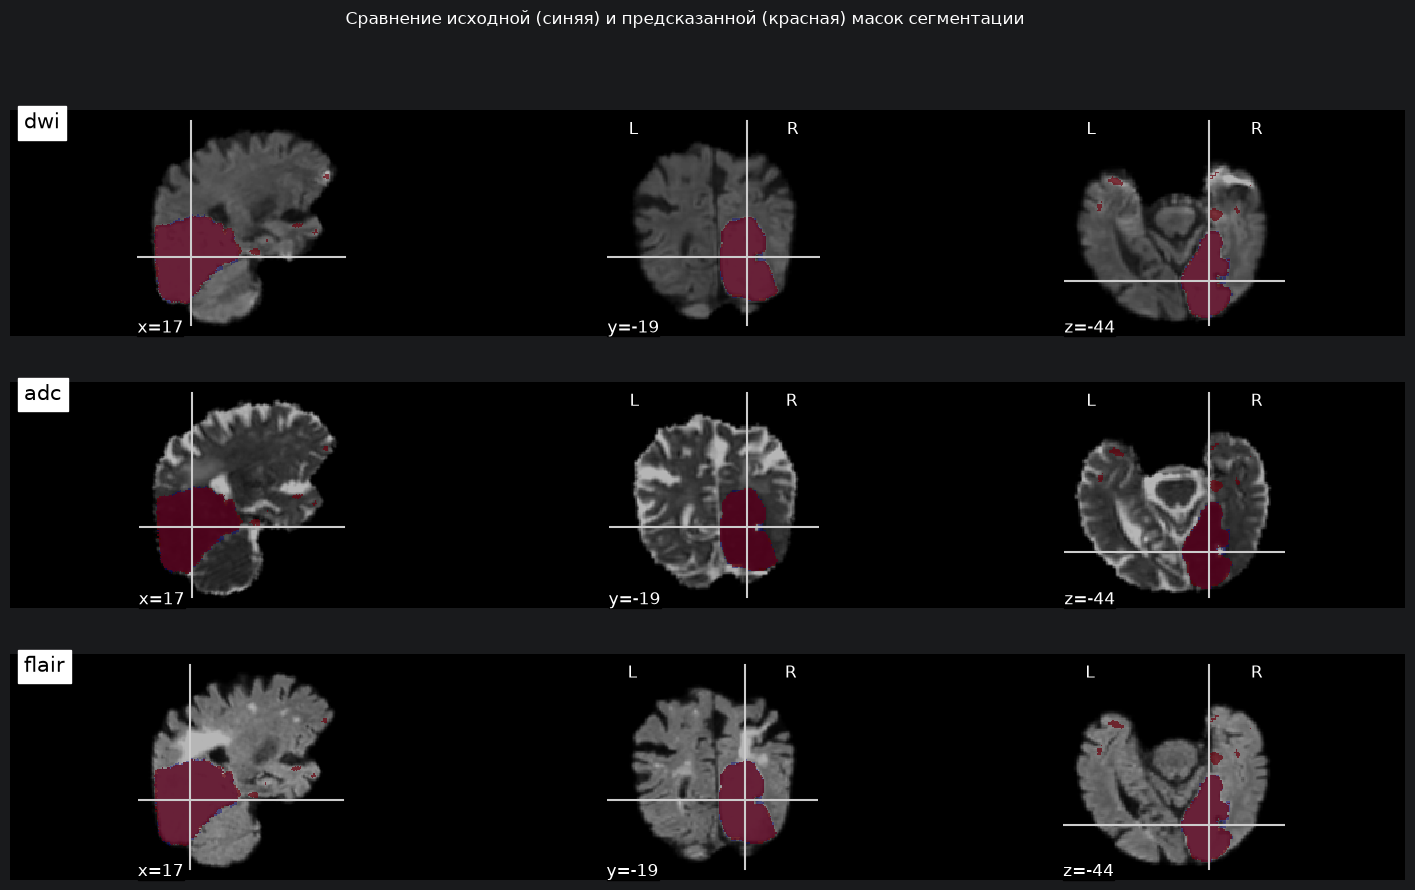

In [14]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

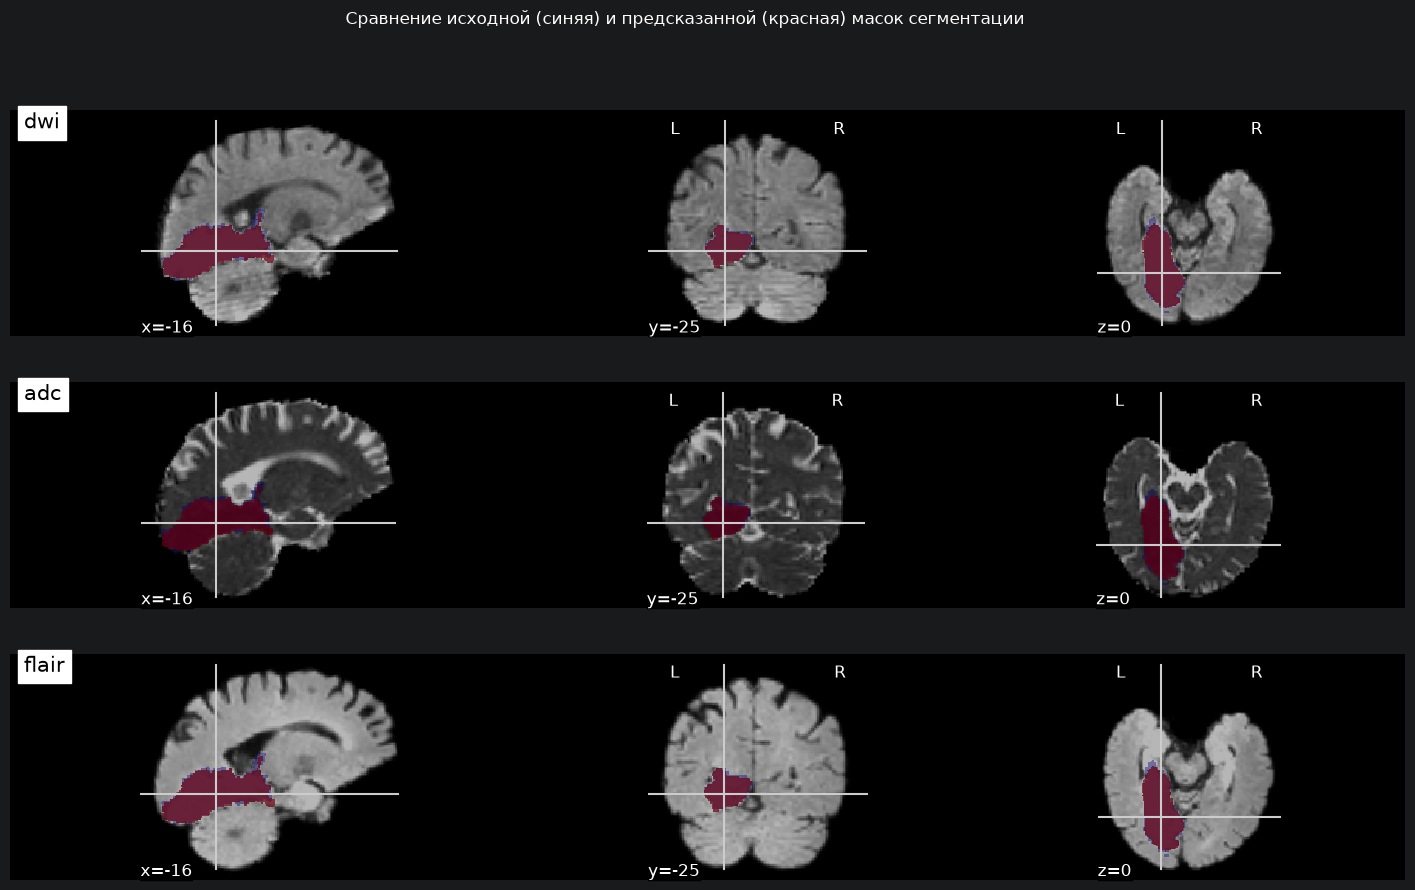

In [15]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

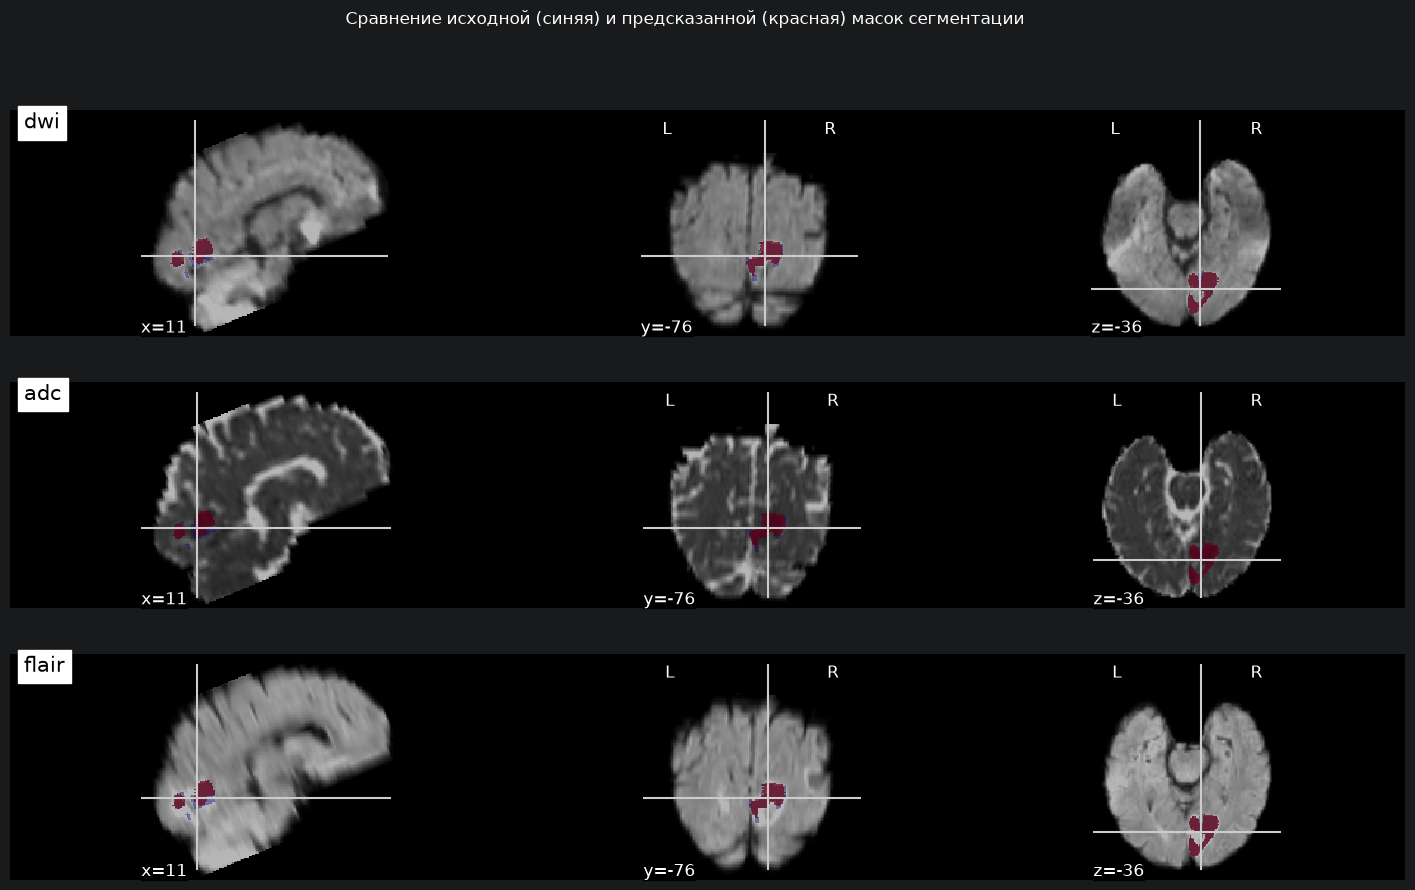

In [16]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, best_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

#### Худшие случаи сегментации

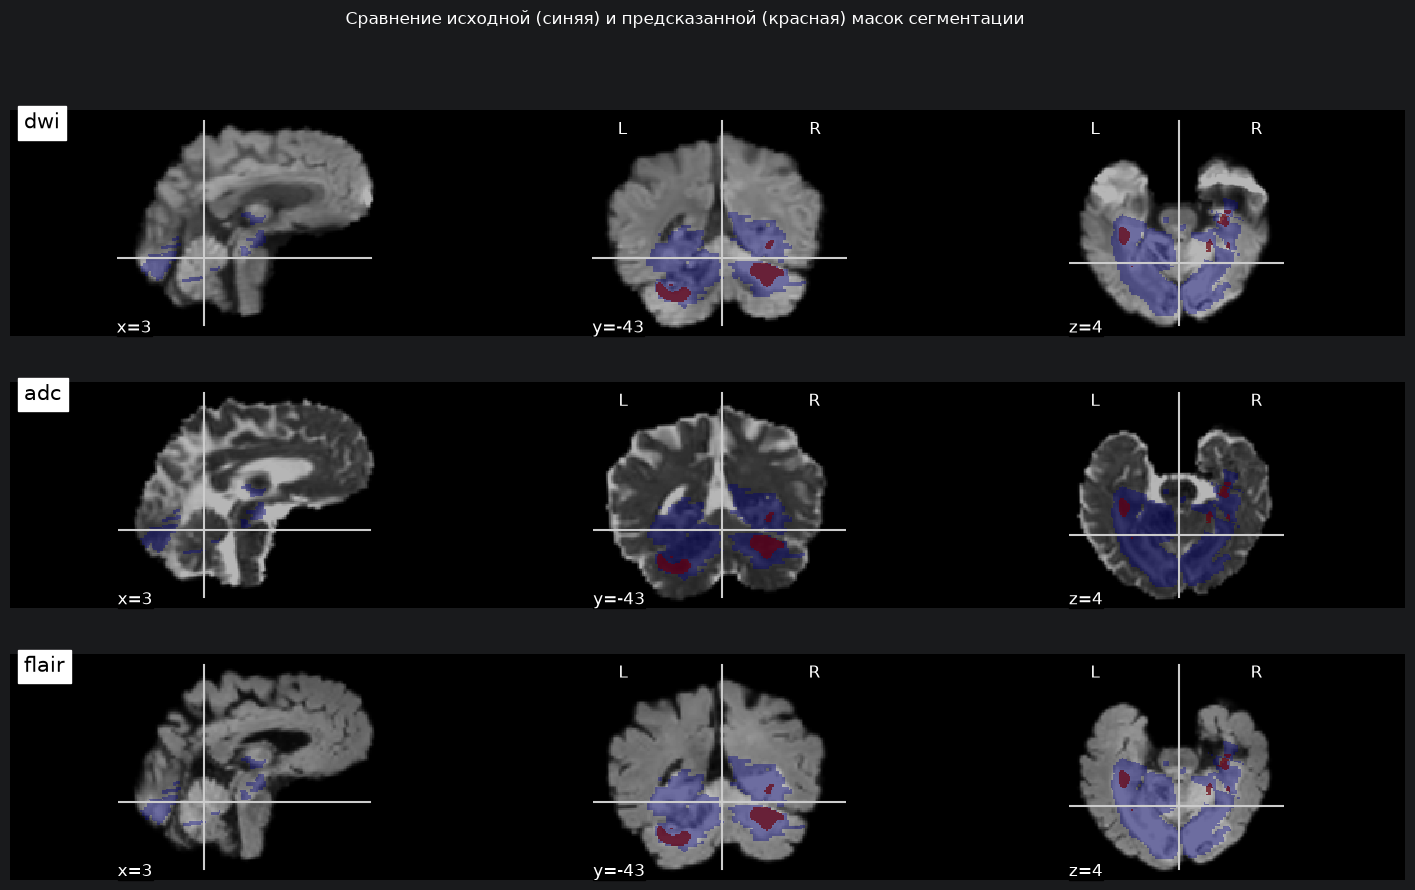

In [17]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[0], ['dwi', 'adc', 'flair'], best_threshold)

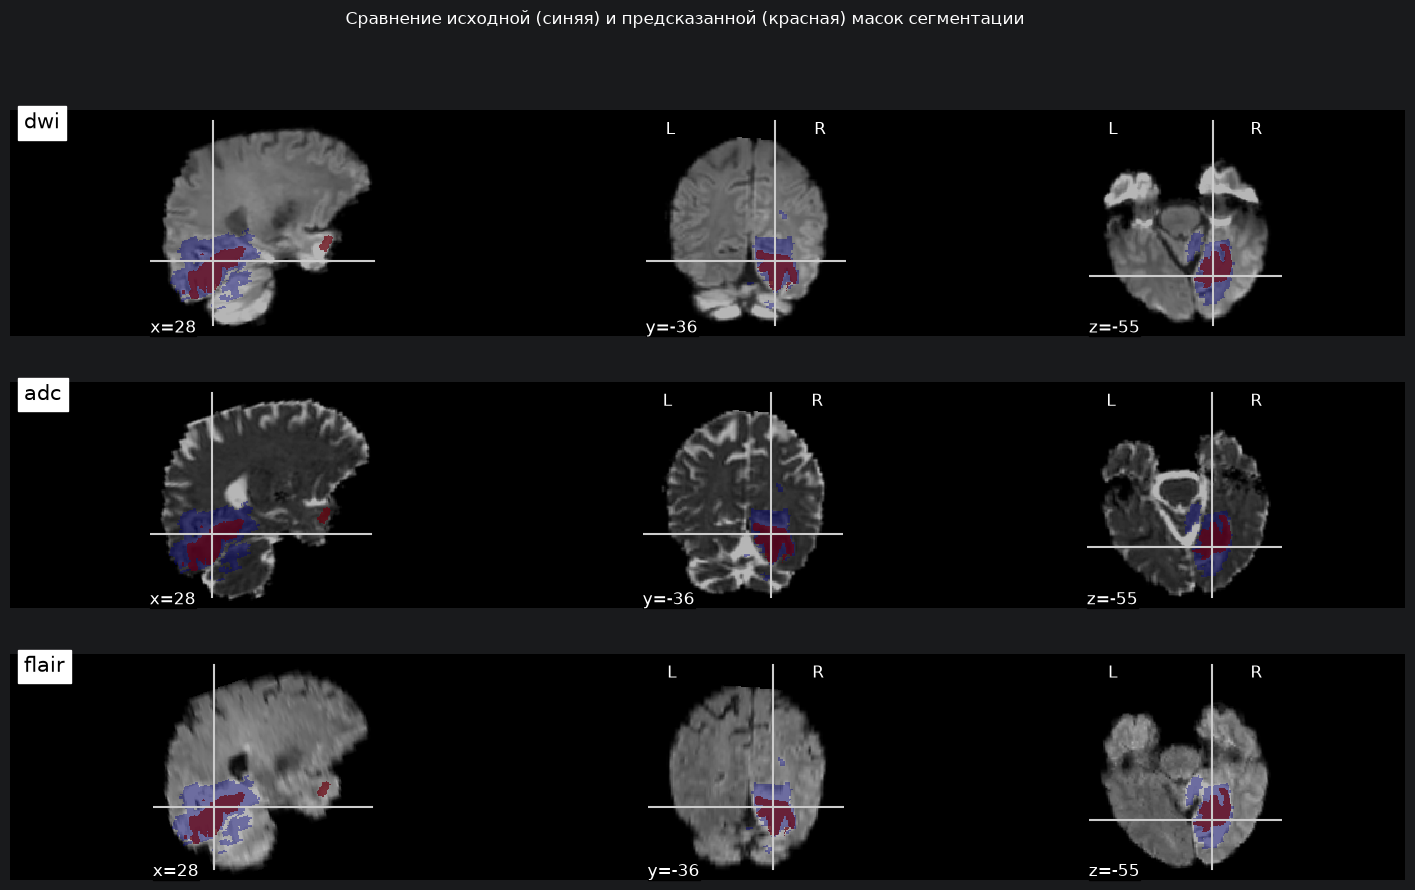

In [18]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[1], ['dwi', 'adc', 'flair'], best_threshold)

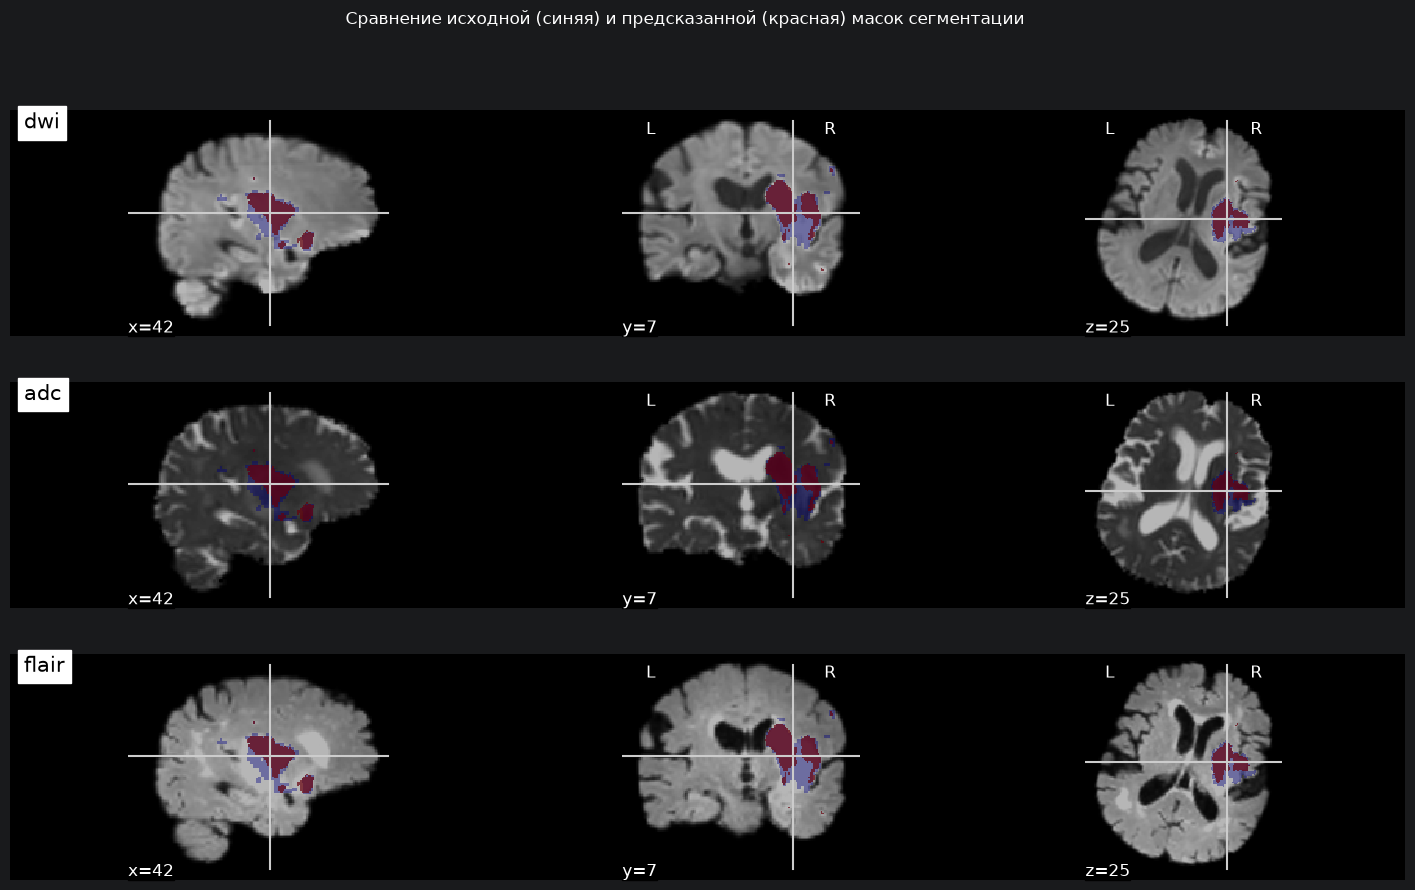

In [19]:
visualize_mri_with_two_mask(unet_plus_plus, test_df, worst_dice_patients_idx[2], ['dwi', 'adc', 'flair'], best_threshold)

Deep supervision также привел к общему снижению качества модели и не повысил качество сегментации очагов малого размера